In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("E:/Luminar/Machine_Learning/World_cup_prediction_model/International football results/results.csv")


In [2]:
country_colors = {
    "Algeria": "#006233",
    "Argentina": "#75AADB",
    "Australia": "#012169",
    "Austria": "#ED2939",
    "Belgium": "#FFD90C",
    "Bosnia and Herzegovina": "#002F6C",
    "Brazil": "#009C3B",
    "Canada": "#D80621",
    "Cape Verde": "#003893",
    "Colombia": "#FCD116",
    "Croatia": "#FF0000",
    "Curaçao": "#0057B8",
    "Czech Republic": "#11457E",
    "DR Congo": "#007FFF",
    "Ecuador": "#FFD100",
    "Egypt": "#CE1126",
    "England": "#C8102E",
    "France": "#0055A4",
    "Germany": "#000000",
    "Ghana": "#CE1126",
    # "Haiti": "#00209F",
    "Iran": "#239F40",
    "Iraq": "#007A3D",
    "Ivory Coast": "#F77F00",
    "Japan": "#BC002D",
    "Jordan": "#007A3D",
    "Mexico": "#006847",
    "Morocco": "#C1272D",
    "Netherlands": "#FF6600",
    "New Zealand": "#00247D",
    "Norway": "#BA0C2F",
    "Panama": "#D21034",
    "Paraguay": "#D52B1E",
    "Portugal": "#046A38",
    "Qatar": "#8A1538",
    "Saudi Arabia": "#006C35",
    "Scotland": "#0065BD",
    "Senegal": "#00853F",
    "South Africa": "#007A4D",
    "South Korea": "#003478",
    "Spain": "#AA151B",
    "Sweden": "#006AA7",
    "Switzerland": "#D52B1E",
    "Tunisia": "#E70013",
    "Turkey": "#E30A17",
    "United States": "#3C3B6E",
    "Uruguay": "#6CB4EE",
    "Uzbekistan": "#0099B5"
}

In [3]:
def get_result(row):
    if row['home_score']>row['away_score']:
        return "H"#home
    elif row['home_score']<row['away_score']:
        return "A"#away
    else:
        return "D"#draw
df["result"] = df.apply(get_result, axis=1)


df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
# df.iloc[1655:1700]

In [4]:
# tournament_weight= {
#     "FIFA World Cup": 5,
#     "FIFA World Cup qualification": 3,
#     "UEFA Euro": 4,
#     "UEFA Euro qualification": 3,
#     "Copa América": 4,
#     "CONMEBOL Nations League": 3,
#     "CONCACAF Nations League": 3,
#     "AFC Asian Cup": 3,
#     "African Cup of Nations": 3,
#     "Friendly": 1
# }
tournament_weight = {
    'Friendly': 1,
    'FIFA World Cup qualification': 3,
    'UEFA Euro qualification': 3,
    'Africa Cup of Nations qualification': 3,
    'Copa América': 4,
    'UEFA Euro': 4,
    'Africa Cup of Nations': 4,
    'FIFA World Cup': 5
}

In [5]:
mask=(df['tournament']=="FIFA World Cup") & (df['date']>='2026-06-11')
df.loc[mask,['home_score','away_score','result']]=np.nan


In [6]:
historical_df=df[df['home_score'].notna()].copy()


historical_df=historical_df[historical_df['date']>='2000-01-01']
# Remove 2026 World Cup matches from historical data
historical_df = historical_df[
    ~(
        (historical_df["tournament"] == "FIFA World Cup") &
        (historical_df["date"] >= "2026-06-01")
    )
].copy()
upcoming_df=df[(df['tournament']=="FIFA World Cup") & (df['date']>='2026-06-11')]
# upcoming_df = (
#     # upcoming_df
#     .sort_values("date")
#     .reset_index(drop=True)
# )
print(len(historical_df))
print(len(upcoming_df))
historical_df
upcoming_df.loc[:,'neutral']=1

hosts = ["Mexico", "Canada", "United States"]

mask = (
    upcoming_df["home_team"].isin(hosts) |
    upcoming_df["away_team"].isin(hosts)
)

upcoming_df.loc[mask, "neutral"] = 0
historical_df=historical_df.sort_values("date").reset_index(drop=True)
historical_df
upcoming_df=upcoming_df.reset_index(drop=True)

25343
72


C:\Users\DELL\AppData\Local\Temp\ipykernel_28028\1415157330.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  upcoming_df.loc[:,'neutral']=1


In [7]:
def calculate_elo(df, k=32, initial=1000):

    elo = {}
    elo_home = []
    elo_away = []

    for _, row in df.iterrows():

        home = row["home_team"]
        away = row["away_team"]

        home_elo = elo.get(home, initial)
        away_elo = elo.get(away, initial)

        elo_home.append(home_elo)
        elo_away.append(away_elo)

        # Expected scores
        expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        expected_away = 1 - expected_home

        # Detect penalty shootout
        is_penalty = (
            row["home_score"] == row["away_score"] and
            row["result"] != "D"
        )

        # Actual scores
        if row["result"] == "H":

            if is_penalty:
                actual_home, actual_away = 0.75, 0.25
            else:
                actual_home, actual_away = 1.0, 0.0

        elif row["result"] == "A":

            if is_penalty:
                actual_home, actual_away = 0.25, 0.75
            else:
                actual_home, actual_away = 0.0, 1.0

        else:
            actual_home, actual_away = 0.5, 0.5

        # Goal difference multiplier
        goal_diff = abs(row["home_score"] - row["away_score"])

        if goal_diff == 1:
            k_adjusted = k
        elif goal_diff == 2:
            k_adjusted = k * 1.25
        else:
            k_adjusted = k * 1.5

        # Update Elo ratings
        elo[home] = home_elo + k_adjusted * (actual_home - expected_home)
        elo[away] = away_elo + k_adjusted * (actual_away - expected_away)

    df["elo_home"] = elo_home
    df["elo_away"] = elo_away

    return df, elo

In [8]:
def get_team_form(team, date, df, n=10):

    past = df[
        (
            (df['home_team'] == team) |
            (df['away_team'] == team)
        ) &
        (df['date'] < date)
    ].tail(n)

    if len(past) == 0:
        return 0, 0, 0, 0, 0

    goal_scored = []
    goal_conceded = []
    goal_difference = []
    wins = []
    draws = []

    for _, row in past.iterrows():

        if row['home_team'] == team:

            scored = row['home_score']
            conceded = row['away_score']

            goal_scored.append(scored)
            goal_conceded.append(conceded)
            goal_difference.append(scored - conceded)

            wins.append(1 if row['result'] == 'H' else 0)
            draws.append(1 if row['result'] == 'D' else 0)

        else:

            scored = row['away_score']
            conceded = row['home_score']

            goal_scored.append(scored)
            goal_conceded.append(conceded)
            goal_difference.append(scored - conceded)

            wins.append(1 if row['result'] == 'A' else 0)
            draws.append(1 if row['result'] == 'D' else 0)

    return (
        round(np.mean(goal_scored), 2),
        round(np.mean(goal_conceded), 2),
        round(np.mean(goal_difference), 2),
        round(np.mean(wins), 2),
        round(np.mean(draws), 2)
    )

In [9]:
#Build Head To Head
def get_h2h(home_team, away_team, date, df):
    c1 = (df['home_team']==home_team) & (df['away_team']==away_team)
    c2 = (df['home_team']==away_team) & (df['away_team']==home_team)
    five_years_ago = date - pd.DateOffset(years=5)
    past = df[(c1 | c2) & (df['date'] < date) & (df['date'] >= five_years_ago)]
    
    if len(past)==0:
        return 0, 0, 0
    home_wins=0
    away_wins=0
    draws=0
    for _,row in past.iterrows():
        if row['result']=="D":
            draws+=1
        elif row["result"]=="H":
            if row["home_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
        elif row["result"]=="A":
            if row["away_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
    

    
    return home_wins, away_wins, draws


In [10]:
def add_team_form_features(fixtures, reference_df):

    home_scored = []
    home_conceded = []
    home_goal_diff = []
    home_win_rate = []
    home_draw_rate = []

    away_scored = []
    away_conceded = []
    away_goal_diff = []
    away_win_rate = []
    away_draw_rate = []

    for _, row in fixtures.iterrows():

        hs, hc, hgd, hw, hd = get_team_form(
            row["home_team"],
            row["date"],
            reference_df
        )

        as_, ac, agd, aw, ad = get_team_form(
            row["away_team"],
            row["date"],
            reference_df
        )

        home_scored.append(hs)
        home_conceded.append(hc)
        home_goal_diff.append(hgd)
        home_win_rate.append(hw)
        home_draw_rate.append(hd)

        away_scored.append(as_)
        away_conceded.append(ac)
        away_goal_diff.append(agd)
        away_win_rate.append(aw)
        away_draw_rate.append(ad)

    fixtures["home_scored"] = home_scored
    fixtures["home_conceded"] = home_conceded
    fixtures["home_goal_diff"] = home_goal_diff
    fixtures["home_win_rate"] = home_win_rate
    fixtures["home_draw_rate"] = home_draw_rate

    fixtures["away_scored"] = away_scored
    fixtures["away_conceded"] = away_conceded
    fixtures["away_goal_diff"] = away_goal_diff
    fixtures["away_win_rate"] = away_win_rate
    fixtures["away_draw_rate"] = away_draw_rate

    return fixtures

In [11]:
def add_h2h_features(fixtures, reference_df):
    fixtures = fixtures.copy()

    h2h_home_wins = []
    h2h_away_wins = []
    h2h_draws = []

    for _, row in fixtures.iterrows():

        home_wins, away_wins, draws = get_h2h(
            row["home_team"],
            row["away_team"],
            row["date"],
            reference_df
        )

        h2h_home_wins.append(home_wins)
        h2h_away_wins.append(away_wins)
        h2h_draws.append(draws)

    fixtures["h2h_home_wins"] = h2h_home_wins
    fixtures["h2h_away_wins"] = h2h_away_wins
    fixtures["h2h_draws"] = h2h_draws

    return fixtures

In [12]:
def engineer_prediction_features(
    fixtures,
    reference_df,
    current_elo
):
    fixtures = fixtures.copy()

    fixtures = add_team_form_features(
        fixtures,
        reference_df
    )

    fixtures = add_h2h_features(
        fixtures,
        reference_df
    )

    fixtures["neutral"] = fixtures["neutral"].astype(int)

    fixtures["tournament_weight"] = (
        fixtures["tournament"]
        .map(tournament_weight)
        .fillna(2)
    )

    fixtures["elo_home"] = (
        fixtures["home_team"]
        .map(current_elo)
        .fillna(1000)
    )

    fixtures["elo_away"] = (
        fixtures["away_team"]
        .map(current_elo)
        .fillna(1000)
    )

    fixtures["elo_diff"] = (
        fixtures["elo_home"]
        - fixtures["elo_away"]
    )

    return fixtures


In [13]:
historical_df['tournament_weight']=(historical_df['tournament'].map(tournament_weight).fillna(2))

In [14]:
historical_df = pd.read_csv(
    "historical_features.csv"
)

historical_df["date"] = pd.to_datetime(
    historical_df["date"]
)

In [15]:
elo_df = pd.read_csv(
    "pre_wc_elo.csv"
)

pre_wc_elo = dict(
    zip(
        elo_df["team"],
        elo_df["elo"]
    )
)

In [16]:
historical_df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,home_win_rate,home_draw_rate,away_scored,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,H,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,H,...,0.0,0.0,1.0,2.0,-1.0,0.0,0.0,0,0,0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,D,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,D,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,D,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25338,2026-06-09,Hungary,Kazakhstan,3.0,1.0,Friendly,Debrecen,Hungary,False,H,...,0.5,0.3,1.0,1.2,-0.2,0.3,0.3,0,0,0
25339,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,Leiria,Portugal,False,H,...,0.6,0.3,2.0,0.6,1.4,0.6,0.4,1,0,0
25340,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,Kansas City,United States,True,A,...,0.3,0.1,1.9,0.4,1.5,0.7,0.2,0,1,0
25341,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,Orlando,United States,True,H,...,0.7,0.1,1.3,1.8,-0.5,0.1,0.6,0,0,0


In [17]:
wc_group_stage = pd.read_csv(
    "wc_group_stage_features.csv"
)

wc_group_stage["date"] = pd.to_datetime(
    wc_group_stage["date"]
)

In [18]:
wc_group_stage

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,tournament_weight,elo_home,elo_away,elo_diff,predicted_result
0,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,0,NaN,...,0.5,0.2,0,0,0,5,1391.378075,1140.026158,251.351917,H
1,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,1,NaN,...,0.5,0.4,0,0,0,5,1315.501633,1260.749755,54.751879,H
2,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,0,NaN,...,0.3,0.6,0,0,0,5,1326.439868,1116.136825,210.303042,H
3,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,0,NaN,...,0.4,0.2,1,0,0,5,1318.998407,1302.882748,16.115658,H
4,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,1,NaN,...,0.5,0.4,0,0,0,5,1056.268658,1356.824879,-300.556221,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,1,NaN,...,0.8,0.1,0,0,0,5,1195.264318,1555.332610,-360.068292,A
68,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,1,NaN,...,0.7,0.2,0,0,0,5,1442.104926,1450.506595,-8.401669,A
69,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,1,NaN,...,0.4,0.3,0,0,0,5,1207.118540,1265.409504,-58.290963,A
70,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,1,NaN,...,0.8,0.1,0,0,0,5,1223.891707,1446.588444,-222.696738,A


In [19]:
features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws',
    'elo_home', 'elo_away','elo_diff','home_draw_rate','away_draw_rate','home_goal_diff',
'away_goal_diff'
    
]

In [20]:
split_date = "2023-01-01"  

train = historical_df[historical_df['date'] < split_date]
test = historical_df[historical_df['date'] >= split_date]

In [21]:
elo_df = pd.DataFrame(
    pre_wc_elo.items(),
    columns=["team", "elo"]
).sort_values("elo",ascending=False)

elo_df.to_csv(
    "pre_wc_elo.csv",
    index=False
)

In [22]:
X = historical_df[features]
y = historical_df['result']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=train[features]
y_train=train["result"]
X_test=test[features]
y_test=test["result"]
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [24]:
def train_models(
    X_train,
    X_train_scaled,
    y_train
):
    models = {}

    # Logistic Regression
    logistic_model = LogisticRegression(
        C= 10,
         max_iter= 500, 
         solver= 'lbfgs'
    )

    logistic_model.fit(
        X_train_scaled,
        y_train
    )

    models["Logistic Regression"] = logistic_model

    # Random Forest
    random_forest_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    random_forest_model.fit(
        X_train,
        y_train
    )

    models["Random Forest"] = random_forest_model

    # XGBoost
    xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

    label_mapping = {
        "A": 0,
        "D": 1,
        "H": 2
    }

    y_train_xgb = y_train.map(label_mapping)

    xgb_model.fit(
        X_train,
        y_train_xgb
    )

    models["XGBoost"] = xgb_model

    return models

In [25]:
from sklearn.model_selection import GridSearchCV


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

lr = LogisticRegression(random_state=42)

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000]
}
lr_grid = GridSearchCV(
    lr,
    lr_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best LR parameters:")
print(lr_grid.best_params_)

print("Best LR CV score:")
print(lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\DELL\AppData\L

Best LR parameters:
{'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best LR CV score:
0.42969595061893484


In [26]:
# rf = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# rf_param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [None, 5, 10, 15, 20],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"]
# }

# rf_grid = GridSearchCV(
#     rf,
#     rf_param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1,
#     verbose=1
# )

# rf_grid.fit(X_train, y_train)

# print("Best RF parameters:")
# print(rf_grid.best_params_)

# print("Best RF CV score:")
# print(rf_grid.best_score_)

# best_rf = rf_grid.best_estimator_
# Fitting 5 folds for each of 270 candidates, totalling 1350 fits
# Best RF parameters:
# {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
# Best RF CV score:
# 0.5759025063232928
# {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

In [27]:
# xgb_mapping = {
#     "A": 0,
#     "D": 1,
#     "H": 2
# }
# xgb_model = XGBClassifier(
#     objective="multi:softprob",
#     num_class=3,
#     eval_metric="mlogloss",
#     random_state=42,
#     n_jobs=-1
# )
# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [3, 5, 6],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

# y_train_xgb = y_train.map(xgb_mapping)
# xgb = XGBClassifier(
#     objective="multi:softprob",
#     num_class=3,
#     eval_metric="mlogloss",
#     random_state=42,
#     n_jobs=-1
# )

# xgb_param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [3, 5, 6],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

# xgb_grid = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring="f1_macro",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# xgb_grid.fit(X_train, y_train_xgb)

# print("Best XGBoost parameters:")
# print(xgb_grid.best_params_)

# print("Best XGBoost CV score:")
# print(xgb_grid.best_score_)

# best_xgb = xgb_grid.best_estimator_

In [28]:
def train_models(
    X_train,
    X_train_scaled,
    y_train
):
    models = {}

    # Logistic Regression
    logistic_model = LogisticRegression(
        C=10, max_iter= 500, solver='lbfgs'
    )

    logistic_model.fit(
        X_train_scaled,
        y_train
    )

    models["Logistic Regression"] = logistic_model

    # Random Forest
    random_forest_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    random_forest_model.fit(
        X_train,
        y_train
    )

    models["Random Forest"] = random_forest_model

    # XGBoost
    xgb_model = XGBClassifier(
    n_estimators=300,
    colsample_bytree=0.8,
    subsample= 0.8,
    max_depth=6,
    learning_rate=0.01,
    random_state=42,
    eval_metric='mlogloss'
)

    label_mapping = {
        "A": 0,
        "D": 1,
        "H": 2
    }

    y_train_xgb = y_train.map(label_mapping)

    xgb_model.fit(
        X_train,
        y_train_xgb
    )

    models["XGBoost"] = xgb_model

    return models

In [29]:
def evaluate_models(
    models,
    X_test,
    X_test_scaled,
    y_test
):
    results = []

    # Logistic Regression
    lr_predictions = models["Logistic Regression"].predict(
        X_test_scaled
    )

    results.append({
        "model": "Logistic Regression",
        "accuracy": accuracy_score(
            y_test,
            lr_predictions
        )
    })

    # Random Forest
    rf_predictions = models["Random Forest"].predict(
        X_test
    )

    results.append({
        "model": "Random Forest",
        "accuracy": accuracy_score(
            y_test,
            rf_predictions
        )
    })

    # XGBoost
    xgb_predictions = models["XGBoost"].predict(
        X_test
    )

    xgb_mapping = {
        0: "A",
        1: "D",
        2: "H"
    }

    xgb_predictions = pd.Series(
        xgb_predictions
    ).map(xgb_mapping)

    results.append({
        "model": "XGBoost",
        "accuracy": accuracy_score(
            y_test,
            xgb_predictions
        )
    })

    return pd.DataFrame(results)

In [30]:
from sklearn.metrics import accuracy_score


In [31]:
models = train_models(
    X_train,
    X_train_scaled,
    y_train
)

In [32]:
evaluation_results = evaluate_models(
    models,
    X_test,
    X_test_scaled,
    y_test
)

evaluation_results


,model,accuracy
0,Logistic Regression,0.607838
1,Random Forest,0.596442
2,XGBoost,0.606448


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():

    if name == "Logistic Regression":
        pred = model.predict(X_test_scaled)

    elif name == "XGBoost":
        pred = model.predict(X_test)
        pred = pd.Series(pred).map({
            0: "A",
            1: "D",
            2: "H"
        }).values

    else:
        pred = model.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(classification_report(
        y_test,
        pred,
        labels=["A", "D", "H"],
        digits=3,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(
        y_test,
        pred,
        labels=["A", "D", "H"]
    ))

    

Logistic Regression
              precision    recall  f1-score   support

           A      0.578     0.647     0.610      1071
           D      0.387     0.015     0.028       827
           H      0.626     0.872     0.729      1700

    accuracy                          0.608      3598
   macro avg      0.530     0.511     0.456      3598
weighted avg      0.557     0.608     0.532      3598

Confusion Matrix:
[[ 693   11  367]
 [ 297   12  518]
 [ 210    8 1482]]
Random Forest
              precision    recall  f1-score   support

           A      0.570     0.615     0.592      1071
           D      0.300     0.058     0.097       827
           H      0.631     0.846     0.723      1700

    accuracy                          0.596      3598
   macro avg      0.500     0.507     0.471      3598
weighted avg      0.537     0.596     0.540      3598

Confusion Matrix:
[[ 659   64  348]
 [ 284   48  495]
 [ 213   48 1439]]
XGBoost
              precision    recall  f1-score   supp

In [34]:
def predict_matches(
    models,
    fixtures,
    features,
    scaler
):
    fixtures = fixtures.copy()

    X = fixtures[features]

    # Logistic Regression
    X_scaled = scaler.transform(X)

    lr_predictions = models["Logistic Regression"].predict(X_scaled)
    lr_probs = models["Logistic Regression"].predict_proba(X_scaled)

    # Random Forest
    rf_predictions = models["Random Forest"].predict(X)
    rf_probs = models["Random Forest"].predict_proba(X)

    # XGBoost
    xgb_predictions = models["XGBoost"].predict(X)
    xgb_probs = models["XGBoost"].predict_proba(X)

    # XGBoost labels
    xgb_mapping = {
        0: "A",
        1: "D",
        2: "H"
    }

    xgb_predictions = pd.Series(
        xgb_predictions
    ).map(xgb_mapping).values

    # Store predictions
    fixtures["lr_prediction"] = lr_predictions
    fixtures["rf_prediction"] = rf_predictions
    fixtures["xgb_prediction"] = xgb_predictions

    # Store probabilities
    fixtures["lr_prob_A"] = lr_probs[:, 0]
    fixtures["lr_prob_D"] = lr_probs[:, 1]
    fixtures["lr_prob_H"] = lr_probs[:, 2]

    fixtures["rf_prob_A"] = rf_probs[:, 0]
    fixtures["rf_prob_D"] = rf_probs[:, 1]
    fixtures["rf_prob_H"] = rf_probs[:, 2]

    fixtures["xgb_prob_A"] = xgb_probs[:, 0]
    fixtures["xgb_prob_D"] = xgb_probs[:, 1]
    fixtures["xgb_prob_H"] = xgb_probs[:, 2]

    return fixtures

In [35]:
def predict_ko_matches(
    models,
    fixtures,
    features,
    scaler
):
    fixtures = fixtures.copy()

    X = fixtures[features]

    # Logistic Regression
    X_scaled = scaler.transform(X)

    lr_probs = models["Logistic Regression"].predict_proba(X_scaled)

    # Random Forest
    rf_probs = models["Random Forest"].predict_proba(X)

    # XGBoost
    xgb_probs = models["XGBoost"].predict_proba(X)

    # Store probabilities
    fixtures["lr_prob_A"] = lr_probs[:, 0]
    fixtures["lr_prob_D"] = lr_probs[:, 1]
    fixtures["lr_prob_H"] = lr_probs[:, 2]

    fixtures["rf_prob_A"] = rf_probs[:, 0]
    fixtures["rf_prob_D"] = rf_probs[:, 1]
    fixtures["rf_prob_H"] = rf_probs[:, 2]

    fixtures["xgb_prob_A"] = xgb_probs[:, 0]
    fixtures["xgb_prob_D"] = xgb_probs[:, 1]
    fixtures["xgb_prob_H"] = xgb_probs[:, 2]

    # Knockout prediction: ignore Draw
    fixtures["lr_prediction"] = np.where(
        fixtures["lr_prob_H"] >= fixtures["lr_prob_A"],
        "H",
        "A"
    )

    fixtures["rf_prediction"] = np.where(
        fixtures["rf_prob_H"] >= fixtures["rf_prob_A"],
        "H",
        "A"
    )

    fixtures["xgb_prediction"] = np.where(
        fixtures["xgb_prob_H"] >= fixtures["xgb_prob_A"],
        "H",
        "A"
    )

    return fixtures

In [36]:
group_stage_predictions = predict_matches(
    models,
    wc_group_stage,
    features,
    scaler
)

In [37]:
group_stage_predictions = group_stage_predictions.drop(
    columns=["predicted_result"],
    errors="ignore"
)

In [38]:
group_stage_predictions[
    [   "date",
        "home_team",
        "away_team",
        "xgb_prediction",
        "lr_prediction",
        "rf_prediction"
    ]
].to_csv(
    "group_stage_predictions.csv",
    index=False
)

In [39]:
gs_actual_results=pd.read_csv(
    "group_stage_actual_results.csv"
)

In [40]:
gs_actual_results = gs_actual_results.loc[
    :,
    ~gs_actual_results.columns.str.startswith("Unnamed:")
]

gs_actual_results.to_csv(
    "group_stage_actual_results.csv",
    index=False
)

In [41]:
gs_actual_results["home_team"] = gs_actual_results["home_team"].replace(
    "Türkiye", "Turkey"
)

gs_actual_results["away_team"] = gs_actual_results["away_team"].replace(
    "Türkiye", "Turkey"
)
gs_actual_results.to_csv("group_stage_actual_results.csv")

In [42]:
from sklearn.metrics import accuracy_score

def check_predictions(predictions_df, actual_results):

    correct = {
        "Logistic Regression": 0,
        "Random Forest": 0,
        "XGBoost": 0
    }

    total = 0

    correct_predictions = {
        "Logistic Regression": [],
        "Random Forest": [],
        "XGBoost": []
    }

    wrong_predictions = {
        "Logistic Regression": [],
        "Random Forest": [],
        "XGBoost": []
    }

    def convert(result, row):

        if result == "H":
            return row["home_team"]

        elif result == "A":
            return row["away_team"]

        else:
            return "Draw"

    def reverse_result(result):

        if result == "H":
            return "A"

        elif result == "A":
            return "H"

        else:
            return "D"

    for _, row in predictions_df.iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # First try normal home/away order
        actual_match = actual_results[
            (actual_results["home_team"] == home) &
            (actual_results["away_team"] == away)
        ]

        reversed_match = False

        # If not found, try reversed home/away order
        if actual_match.empty:

            actual_match = actual_results[
                (actual_results["home_team"] == away) &
                (actual_results["away_team"] == home)
            ]

            reversed_match = True

        # Skip only if the match cannot be found at all
        if actual_match.empty:
            continue

        actual = actual_match.iloc[0]["actual_result"]

        # If actual-results has the teams reversed,
        # reverse H <-> A
        if reversed_match:
            actual = reverse_result(actual)

        total += 1

        predictions = {
            "Logistic Regression": row["lr_prediction"],
            "Random Forest": row["rf_prediction"],
            "XGBoost": row["xgb_prediction"]
        }

        match_key = f"{home} vs {away}"

        for model, predicted in predictions.items():

            if actual == predicted:

                correct[model] += 1

                correct_predictions[model].append(
                    f"{match_key}: "
                    f"prediction: {convert(predicted, row)}, "
                    f"actual: {convert(actual, row)}"
                )

            else:

                wrong_predictions[model].append(
                    f"{match_key}: "
                    f"prediction: {convert(predicted, row)}, "
                    f"actual: {convert(actual, row)}"
                )

    print(f"Total matches evaluated: {total}")

    print("\nAccuracy:")

    for model in correct:

        accuracy = (correct[model] / total) * 100

        print(
            f"{model}: "
            f"{correct[model]}/{total} "
            f"({accuracy:.2f}%)"
        )

    print("\nCorrect Predictions:")

    for model in correct_predictions:

        print(f"\n--- {model} ---")

        for prediction in correct_predictions[model]:
            print(prediction)

    return correct_predictions, wrong_predictions

In [43]:
correct_predictions, wrong_predictions = check_predictions(
    group_stage_predictions,
    gs_actual_results
)
wrong_predictions

Total matches evaluated: 72

Accuracy:
Logistic Regression: 43/72 (59.72%)
Random Forest: 44/72 (61.11%)
XGBoost: 43/72 (59.72%)

Correct Predictions:

--- Logistic Regression ---
Mexico vs South Africa: prediction: Mexico, actual: Mexico
South Korea vs Czech Republic: prediction: South Korea, actual: South Korea
United States vs Paraguay: prediction: United States, actual: United States
Haiti vs Scotland: prediction: Scotland, actual: Scotland
Germany vs Curaçao: prediction: Germany, actual: Germany
Sweden vs Tunisia: prediction: Sweden, actual: Sweden
France vs Senegal: prediction: France, actual: France
Iraq vs Norway: prediction: Norway, actual: Norway
Argentina vs Algeria: prediction: Argentina, actual: Argentina
Austria vs Jordan: prediction: Austria, actual: Austria
Uzbekistan vs Colombia: prediction: Colombia, actual: Colombia
England vs Croatia: prediction: England, actual: England
Mexico vs South Korea: prediction: Mexico, actual: Mexico
Switzerland vs Bosnia and Herzegovina:

{'Logistic Regression': ['Canada vs Bosnia and Herzegovina: prediction: Canada, actual: Draw',
  'Qatar vs Switzerland: prediction: Switzerland, actual: Draw',
  'Brazil vs Morocco: prediction: Morocco, actual: Draw',
  'Australia vs Turkey: prediction: Turkey, actual: Australia',
  'Ivory Coast vs Ecuador: prediction: Ecuador, actual: Ivory Coast',
  'Netherlands vs Japan: prediction: Japan, actual: Draw',
  'Belgium vs Egypt: prediction: Belgium, actual: Draw',
  'Iran vs New Zealand: prediction: Iran, actual: Draw',
  'Spain vs Cape Verde: prediction: Spain, actual: Draw',
  'Saudi Arabia vs Uruguay: prediction: Uruguay, actual: Draw',
  'Portugal vs DR Congo: prediction: Portugal, actual: Draw',
  'Ghana vs Panama: prediction: Panama, actual: Ghana',
  'Czech Republic vs South Africa: prediction: Czech Republic, actual: Draw',
  'Turkey vs Paraguay: prediction: Turkey, actual: Paraguay',
  'Ecuador vs Curaçao: prediction: Ecuador, actual: Draw',
  'Belgium vs Iran: prediction: Belg

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def group_stage_plot_probs(predictions_df, model="XGBoost"):

    model_prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }

    prefix = model_prefix[model]

    # Match names
    matches = (
        predictions_df["home_team"] 
        + " vs " 
        + predictions_df["away_team"]
    )

    # Probabilities
    prob_A = predictions_df[f"{prefix}_prob_A"]
    prob_D = predictions_df[f"{prefix}_prob_D"]
    prob_H = predictions_df[f"{prefix}_prob_H"]

    x = np.arange(len(matches))
    width = 0.25

    plt.figure(figsize=(22, 8))

    plt.bar(
        x - width,
        prob_H,
        width,
        label="Home Win"
    )

    plt.bar(
        x,
        prob_D,
        width,
        label="Draw"
    )

    plt.bar(
        x + width,
        prob_A,
        width,
        label="Away Win"
    )

    plt.xlabel("Match")
    plt.ylabel("Probability")
    plt.title(f"{model} - World Cup Group Stage Result Predictions")

    plt.xticks(
        x,
        matches,
        rotation=90
    )

    plt.ylim(0, 1)

    plt.legend()

    plt.tight_layout()

    plt.show()

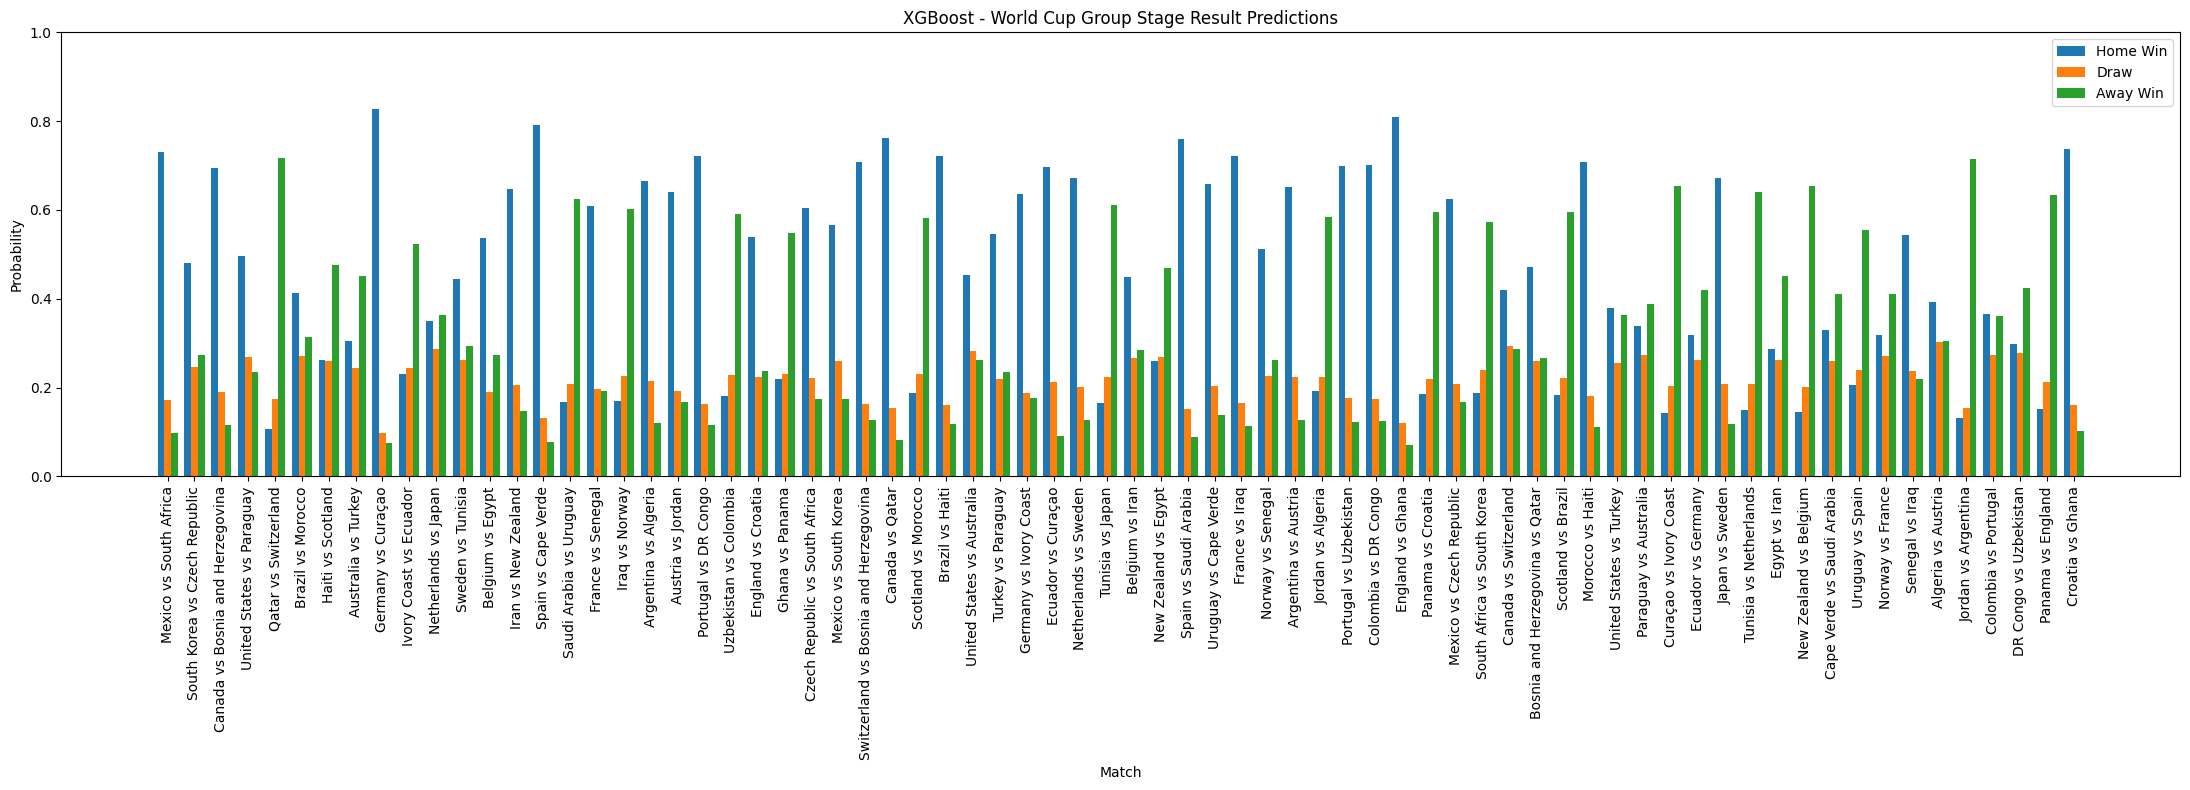

In [45]:
group_stage_plot_probs(
    group_stage_predictions,
    "XGBoost"
)

In [46]:
def single_match_probs(
    predictions_df,
    home_team,
    away_team,
    model="XGBoost"
):

    # Find the match
    match = predictions_df[
        (predictions_df["home_team"] == home_team) &
        (predictions_df["away_team"] == away_team)
    ]

    if match.empty:
        print(f"Match not found: {home_team} vs {away_team}")
        return

    row = match.iloc[0]

    # Select probability columns
    prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }[model]

    home_prob = row[f"{prefix}_prob_H"]
    draw_prob = row[f"{prefix}_prob_D"]
    away_prob = row[f"{prefix}_prob_A"]

    prediction = row[f"{prefix}_prediction"]

    # Convert prediction to readable result
    if prediction == "H":
        predicted_result = home_team
    elif prediction == "A":
        predicted_result = away_team
    else:
        predicted_result = "Draw"

    print(f"\n{home_team} vs {away_team}")
    print(f"Model: {model}")

    print(f"\n{home_team} win : {home_prob * 100:.2f}%")
    print(f"Draw          : {draw_prob * 100:.2f}%")
    print(f"{away_team} win : {away_prob * 100:.2f}%")

    print(f"\nPrediction: {predicted_result}")

In [47]:
single_match_probs(
    group_stage_predictions,
    "Spain",
    "Cape Verde",
    "XGBoost"
)


Spain vs Cape Verde
Model: XGBoost

Spain win : 79.06%
Draw          : 13.19%
Cape Verde win : 7.75%

Prediction: Spain


In [48]:


def plot_single_match_probs(
    predictions_df,
    home_team,
    away_team,
    model="XGBoost"
):

    model_prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }

    prefix = model_prefix[model]

    # Find match
    match = predictions_df[
        (predictions_df["home_team"] == home_team) &
        (predictions_df["away_team"] == away_team)
    ]

    if match.empty:
        print(f"Match not found: {home_team} vs {away_team}")
        return

    match = match.iloc[0]

    # Probabilities
    home_prob = match[f"{prefix}_prob_H"]
    draw_prob = match[f"{prefix}_prob_D"]
    away_prob = match[f"{prefix}_prob_A"]

    labels = [
        home_team,
        "Draw",
        away_team
    ]

    probabilities = [
        home_prob,
        draw_prob,
        away_prob
    ]

    # Country colors
    colors = [
        country_colors[home_team],
        "gray",
        country_colors[away_team]
    ]

    # Horizontal bar chart
    plt.figure(figsize=(9, 4))

    bars = plt.barh(
        labels,
        probabilities,
        color=colors
    )

    # Percentage labels
    for bar, probability in zip(bars, probabilities):

        plt.text(
            probability + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{probability * 100:.1f}%",
            va="center",
            fontweight="bold"
        )

    plt.xlabel("Probability")

    plt.title(
        f"{home_team} vs {away_team} - {model}"
    )

    plt.xlim(0, 1)

    plt.grid(
        axis="x",
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

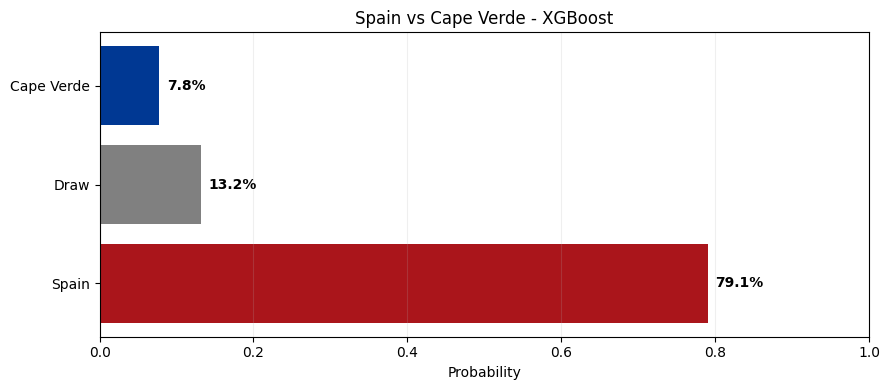

In [49]:
plot_single_match_probs(
    group_stage_predictions,
    "Spain",
    "Cape Verde",
    "XGBoost"
)

In [50]:
features

['home_scored',
 'home_conceded',
 'home_win_rate',
 'away_scored',
 'away_conceded',
 'away_win_rate',
 'neutral',
 'tournament_weight',
 'h2h_home_wins',
 'h2h_away_wins',
 'h2h_draws',
 'elo_home',
 'elo_away',
 'elo_diff',
 'home_draw_rate',
 'away_draw_rate',
 'home_goal_diff',
 'away_goal_diff']

In [51]:
historical_df.tail(72)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,home_win_rate,home_draw_rate,away_scored,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws
25271,2026-06-05,Georgia,Bahrain,2.0,0.0,Friendly,Tbilisi,Georgia,False,H,...,0.2,0.3,0.9,1.7,-0.8,0.2,0.1,0,0,0
25272,2026-06-05,Canada,Republic of Ireland,1.0,1.0,Friendly,Montreal,Canada,False,D,...,0.4,0.5,1.7,0.9,0.8,0.5,0.3,0,0,0
25273,2026-06-05,Belarus,Syria,4.0,1.0,Friendly,Minsk,Belarus,False,H,...,0.3,0.2,2.0,0.8,1.2,0.5,0.3,1,0,0
25274,2026-06-05,Azerbaijan,Malta,0.0,2.0,Friendly,Szombathely,Hungary,True,A,...,0.1,0.3,0.9,2.5,-1.6,0.2,0.2,0,1,0
25275,2026-06-05,Angola,Mauritania,1.0,1.0,Friendly,Casablanca,Morocco,True,D,...,0.2,0.4,0.5,1.2,-0.7,0.1,0.4,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25338,2026-06-09,Hungary,Kazakhstan,3.0,1.0,Friendly,Debrecen,Hungary,False,H,...,0.5,0.3,1.0,1.2,-0.2,0.3,0.3,0,0,0
25339,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,Leiria,Portugal,False,H,...,0.6,0.3,2.0,0.6,1.4,0.6,0.4,1,0,0
25340,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,Kansas City,United States,True,A,...,0.3,0.1,1.9,0.4,1.5,0.7,0.2,0,1,0
25341,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,Orlando,United States,True,H,...,0.7,0.1,1.3,1.8,-0.5,0.1,0.6,0,0,0


In [52]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    models["Logistic Regression"],
    "models/logistic_model.pkl"
)

joblib.dump(
    models["Random Forest"],
    "models/random_forest_model.pkl"
)

joblib.dump(
    models["XGBoost"],
    "models/xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "models/result_scaler.pkl"
)

print("Result models saved successfully.")

Result models saved successfully.


In [53]:
def prepare_round_features(fixtures, reference_df, current_elo):
    
    # Make a copy so the original fixture dataframe isn't changed
    fixtures = fixtures.copy()
    
    # Convert date to datetime
    fixtures["date"] = pd.to_datetime(fixtures["date"])
    
    # Add tournament
    fixtures["tournament"] = "FIFA World Cup"
    
    # Calculate all required features
    round_features = engineer_prediction_features(
        fixtures,
        reference_df,
        current_elo
    )
    
    return round_features

In [54]:
gs_actual_results

,date,home_team,away_team,home_score,away_score,actual_result
0,2026-06-11,Mexico,South Africa,2,0,H
1,2026-06-11,South Korea,Czech Republic,2,1,H
2,2026-06-12,Canada,Bosnia and Herzegovina,1,1,D
3,2026-06-12,United States,Paraguay,4,1,H
4,2026-06-13,Qatar,Switzerland,1,1,D
...,...,...,...,...,...,...
67,2026-06-27,Croatia,Ghana,2,1,H
68,2026-06-27,Colombia,Portugal,0,0,D
69,2026-06-27,DR Congo,Uzbekistan,3,1,H
70,2026-06-28,Algeria,Austria,3,3,D


In [55]:
historical_df[["home_team","away_team","elo_home","elo_away"]].tail()

,home_team,away_team,elo_home,elo_away
25338,Hungary,Kazakhstan,1229.558543,979.180613
25339,Portugal,Nigeria,1441.022265,1290.830988
25340,Bolivia,Algeria,1133.914191,1334.186312
25341,England,Costa Rica,1438.194273,1168.681748
25342,Afghanistan,Pakistan,731.014788,668.260221


In [56]:
def update_tournament_state(reference_df, actual_results):
    
    # Keep only actual match results
    actual_results = actual_results.copy()

    # Remove accidental CSV index columns
    actual_results = actual_results.loc[
        :,
        ~actual_results.columns.str.startswith("Unnamed:")
    ]

    # Make sure dates are datetime
    reference_df = reference_df.copy()
    reference_df["date"] = pd.to_datetime(reference_df["date"])
    actual_results["date"] = pd.to_datetime(actual_results["date"])

    # Use "result" consistently
    if "actual_result" in actual_results.columns:
        actual_results["result"] = actual_results["actual_result"]

    # Make sure neutral is numeric
    actual_results["neutral"] = 1
    
    # Add actual results to match history
    updated_df = pd.concat(
        [reference_df, actual_results],
        ignore_index=True
    )

    # Remove duplicate matches
    updated_df = (
        updated_df
        .sort_values("date")
        .drop_duplicates(
            subset=["date", "home_team", "away_team"],
            keep="last"
        )
        .reset_index(drop=True)
    )

    # Recalculate Elo chronologically
    updated_df, updated_elo = calculate_elo(
        updated_df
    )

    # Recalculate form features
    updated_df = add_team_form_features(
        updated_df,
        updated_df
    )

# Calculate Elo difference
    updated_df["elo_diff"] = (
    updated_df["elo_home"] -
    updated_df["elo_away"]
)


    # Recalculate H2H features
    updated_df = add_h2h_features(
        updated_df,
        updated_df
    )

    # Tournament weight
    updated_df["tournament_weight"] = (
        updated_df["tournament"]
        .map(tournament_weight)
        .fillna(2)
    )

    return updated_df, updated_elo

In [57]:
def prepare_round_features(fixtures, reference_df, current_elo):
    
    # Make a copy so the original fixture dataframe isn't changed
    fixtures = fixtures.copy()
    
    # Convert date to datetime
    fixtures["date"] = pd.to_datetime(fixtures["date"])
    
    # Add tournament
    fixtures["tournament"] = "FIFA World Cup"
    
    # Calculate all required features
    round_features = engineer_prediction_features(
        fixtures,
        reference_df,
        current_elo
    )
    
    return round_features

In [58]:
post_gs_df= pd.read_csv("post_group_stage_features.csv")
post_gs_updated_elo=pd.read_csv("post_group_stage_elo.csv")
post_gs_elo = dict(
    zip(
        post_gs_updated_elo["team"],
        post_gs_updated_elo["elo"]
    )
)

In [59]:
host_teams = ["Mexico", "Canada", "United States"]

mask = (
    (post_gs_df["date"] >= "2026-06-11") & 
    post_gs_df["home_team"].isin(host_teams)
)

post_gs_df.loc[mask, "neutral"] = 0

In [60]:
post_gs_df.to_csv(
    "post_group_stage_features.csv",
    index=False
)

In [61]:
pd.read_csv("post_group_stage_features.csv").shape

(25414, 30)

In [62]:
pre_wc_elo['Argentina']

1555.332610428662

In [63]:
post_gs_updated_elo

,team,elo
0,Argentina,1578.833574
1,Spain,1526.183868
2,France,1511.183089
3,Brazil,1465.058592
4,Colombia,1458.668205
...,...,...
316,Anguilla,537.614339
317,Timor-Leste,510.265870
318,San Marino,493.287949
319,Macau,489.111355


In [64]:
post_gs_elo['Argentina']

1578.8335742654983

In [65]:
r32_fixtures = pd.DataFrame([
    {"home_team": "South Africa", "away_team": "Canada", "date": "2026-06-28", "neutral": 1},
    {"home_team": "Brazil", "away_team": "Japan", "date": "2026-06-29", "neutral": 1},
    {"home_team": "Germany", "away_team": "Paraguay", "date": "2026-06-29", "neutral": 1},
    {"home_team": "Netherlands", "away_team": "Morocco", "date": "2026-06-30", "neutral": 1},
    {"home_team": "Ivory Coast", "away_team": "Norway", "date": "2026-06-30", "neutral": 1},
    {"home_team": "France", "away_team": "Sweden", "date": "2026-06-30", "neutral": 1},
    {"home_team": "Mexico", "away_team": "Ecuador", "date": "2026-07-01", "neutral": 0},
    {"home_team": "England", "away_team": "DR Congo", "date": "2026-07-01", "neutral": 1},
    {"home_team": "Belgium", "away_team": "Senegal", "date": "2026-07-02", "neutral": 1},
    {"home_team": "United States", "away_team": "Bosnia and Herzegovina", "date": "2026-07-02", "neutral": 0},
    {"home_team": "Spain", "away_team": "Austria", "date": "2026-07-03", "neutral": 1},
    {"home_team": "Portugal", "away_team": "Croatia", "date": "2026-07-03", "neutral": 1},
    {"home_team": "Switzerland", "away_team": "Algeria", "date": "2026-07-03", "neutral": 1},
    {"home_team": "Australia", "away_team": "Egypt", "date": "2026-07-03", "neutral": 1},
    {"home_team": "Argentina", "away_team": "Cape Verde", "date": "2026-07-03", "neutral": 1},
    {"home_team": "Colombia", "away_team": "Ghana", "date": "2026-07-03", "neutral": 1}
])

r32_fixtures["date"] = pd.to_datetime(r32_fixtures["date"])

In [66]:
post_gs_df["date"] = pd.to_datetime(post_gs_df["date"])
r32_fixtures["date"] = pd.to_datetime(r32_fixtures["date"])
r32_fixtures["tournament"] = "FIFA World Cup"

In [67]:
r32_features = engineer_prediction_features(
    r32_fixtures,
    post_gs_df,
    post_gs_elo
)

In [68]:
r32_features[["home_team","away_team"]+features]

,home_team,away_team,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,neutral,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff,home_draw_rate,away_draw_rate,home_goal_diff,away_goal_diff
0,South Africa,Canada,0.9,1.1,0.3,1.5,0.6,0.3,1,5,0,0,0,1163.539495,1308.363916,-144.824421,0.3,0.6,-0.2,0.9
1,Brazil,Japan,2.4,1.1,0.6,2.0,0.7,0.7,1,5,1,1,0,1465.058592,1428.501719,36.556874,0.2,0.3,1.3,1.3
2,Germany,Paraguay,3.1,0.9,0.9,1.3,1.3,0.4,1,5,0,0,0,1431.930805,1300.385177,131.545628,0.0,0.2,2.2,0.0
3,Netherlands,Morocco,2.4,0.9,0.6,2.2,0.6,0.6,1,5,0,0,0,1433.868522,1442.258543,-8.390021,0.3,0.4,1.5,1.6
4,Ivory Coast,Norway,2.0,0.9,0.7,2.2,1.4,0.5,1,5,0,0,0,1309.386192,1372.815549,-63.429357,0.1,0.3,1.1,0.8
5,France,Sweden,2.8,1.0,0.8,1.8,2.1,0.3,1,5,0,0,0,1511.183089,1247.723054,263.460035,0.1,0.3,1.8,-0.3
6,Mexico,Ecuador,2.0,0.2,0.8,1.2,0.6,0.4,0,5,0,1,3,1424.808327,1381.813368,42.994959,0.2,0.5,1.8,0.6
7,England,DR Congo,2.0,0.4,0.7,1.2,0.7,0.4,1,5,0,0,0,1450.876809,1236.506692,214.370117,0.2,0.3,1.6,0.5
8,Belgium,Senegal,3.1,0.8,0.6,1.7,1.3,0.5,1,5,0,0,0,1373.554838,1308.584808,64.970030,0.4,0.1,2.3,0.4
9,United States,Bosnia and Herzegovina,2.3,1.8,0.6,1.6,1.2,0.3,0,5,1,0,0,1344.124665,1135.004522,209.120142,0.0,0.6,0.5,0.4


In [69]:
# R32 model features
X_r32 = r32_features[features]

# Scale using the scaler fitted on the original training data
X_r32_scaled = scaler.transform(X_r32)

In [70]:
r32_predictions = predict_ko_matches(
    models,
    r32_features,
    features,
    scaler
)

In [71]:
r32_predictions

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,South Africa,Canada,2026-06-28,1,FIFA World Cup,0.9,1.1,-0.2,0.3,0.3,...,0.158744,0.47,0.22,0.31,0.559825,0.237020,0.203154,A,A,A
1,Brazil,Japan,2026-06-29,1,FIFA World Cup,2.4,1.1,1.3,0.6,0.2,...,0.446935,0.32,0.18,0.50,0.294511,0.245722,0.459767,H,H,H
2,Germany,Paraguay,2026-06-29,1,FIFA World Cup,3.1,0.9,2.2,0.9,0.0,...,0.572809,0.20,0.19,0.61,0.208577,0.190408,0.601014,H,H,H
3,Netherlands,Morocco,2026-06-30,1,FIFA World Cup,2.4,0.9,1.5,0.6,0.3,...,0.337579,0.29,0.29,0.42,0.349336,0.284691,0.365973,A,H,H
4,Ivory Coast,Norway,2026-06-30,1,FIFA World Cup,2.0,0.9,1.1,0.7,0.1,...,0.268562,0.55,0.22,0.23,0.465148,0.248541,0.286310,A,A,A
5,France,Sweden,2026-06-30,1,FIFA World Cup,2.8,1.0,1.8,0.8,0.1,...,0.775419,0.17,0.30,0.53,0.122106,0.168224,0.709670,H,H,H
6,Mexico,Ecuador,2026-07-01,0,FIFA World Cup,2.0,0.2,1.8,0.8,0.2,...,0.438086,0.26,0.36,0.38,0.193836,0.311297,0.494867,H,H,H
7,England,DR Congo,2026-07-01,1,FIFA World Cup,2.0,0.4,1.6,0.7,0.2,...,0.687628,0.04,0.09,0.87,0.111884,0.200981,0.687134,H,H,H
8,Belgium,Senegal,2026-07-02,1,FIFA World Cup,3.1,0.8,2.3,0.6,0.4,...,0.517758,0.13,0.15,0.72,0.237908,0.210460,0.551632,H,H,H
9,United States,Bosnia and Herzegovina,2026-07-02,0,FIFA World Cup,2.3,1.8,0.5,0.6,0.0,...,0.790310,0.07,0.27,0.66,0.113266,0.165158,0.721576,H,H,H


In [72]:
def knockout_plot_probs(predictions_df, model="XGBoost"):

    model_prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }

    prefix = model_prefix[model]

    # Match names
    matches = (
        predictions_df["home_team"] 
        + " vs " 
        + predictions_df["away_team"]
    )

    # Probabilities
    prob_A = predictions_df[f"{prefix}_prob_A"]
    prob_D = predictions_df[f"{prefix}_prob_D"]
    prob_H = predictions_df[f"{prefix}_prob_H"]

    x = np.arange(len(matches))
    width = 0.25

    plt.figure(figsize=(22, 8))

    plt.bar(
        x - width,
        prob_H,
        width,
        label="Home Win"
    )

    plt.bar(
        x,
        prob_D,
        width,
        label="Extra Time/Penalties"
    )

    plt.bar(
        x + width,
        prob_A,
        width,
        label="Away Win"
    )

    plt.xlabel("Match")
    plt.ylabel("Probability")
    plt.title(f"{model} - World Cup Group Stage Result Predictions")

    plt.xticks(
        x,
        matches,
        rotation=90
    )

    plt.ylim(0, 1)

    plt.legend()

    plt.tight_layout()

    plt.show()

def ko_single_match_probs(
    predictions_df,
    home_team,
    away_team,
    model="XGBoost"
):

    # Find the match
    match = predictions_df[
        (predictions_df["home_team"] == home_team) &
        (predictions_df["away_team"] == away_team)
    ]

    if match.empty:
        print(f"Match not found: {home_team} vs {away_team}")
        return

    row = match.iloc[0]

    # Select probability columns
    prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }[model]

    home_prob = row[f"{prefix}_prob_H"]
    draw_prob = row[f"{prefix}_prob_D"]
    away_prob = row[f"{prefix}_prob_A"]

    prediction = row[f"{prefix}_prediction"]

    # Convert prediction to readable result
    if prediction == "H":
        predicted_result = home_team
    elif prediction == "A":
        predicted_result = away_team
    else:
        predicted_result = "Draw"

    print(f"\n{home_team} vs {away_team}")
    print(f"Model: {model}")

    print(f"\n{home_team} win : {home_prob * 100:.2f}%")
    print(f"Extra time/Penalties          : {draw_prob * 100:.2f}%")
    print(f"{away_team} win : {away_prob * 100:.2f}%")

    print(f"\nPrediction: {predicted_result}")

def ko_plot_single_match_probs(
    predictions_df,
    home_team,
    away_team,
    model="XGBoost"
):

    model_prefix = {
        "Logistic Regression": "lr",
        "Random Forest": "rf",
        "XGBoost": "xgb"
    }

    prefix = model_prefix[model]

    # Find match
    match = predictions_df[
        (predictions_df["home_team"] == home_team) &
        (predictions_df["away_team"] == away_team)
    ]

    if match.empty:
        print(f"Match not found: {home_team} vs {away_team}")
        return

    match = match.iloc[0]

    # Probabilities
    home_prob = match[f"{prefix}_prob_H"]
    draw_prob = match[f"{prefix}_prob_D"]
    away_prob = match[f"{prefix}_prob_A"]

    labels = [
        home_team,
        "Extra Time/Penalties",
        away_team
    ]

    probabilities = [
        home_prob,
        draw_prob,
        away_prob
    ]

    # Country colors
    colors = [
        country_colors[home_team],
        "gray",
        country_colors[away_team]
    ]

    # Horizontal bar chart
    plt.figure(figsize=(9, 4))

    bars = plt.barh(
        labels,
        probabilities,
        color=colors
    )

    # Percentage labels
    for bar, probability in zip(bars, probabilities):

        plt.text(
            probability + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{probability * 100:.1f}%",
            va="center",
            fontweight="bold"
        )

    plt.xlabel("Probability")

    plt.title(
        f"{home_team} vs {away_team} - {model}"
    )

    plt.xlim(0, 1)

    plt.grid(
        axis="x",
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

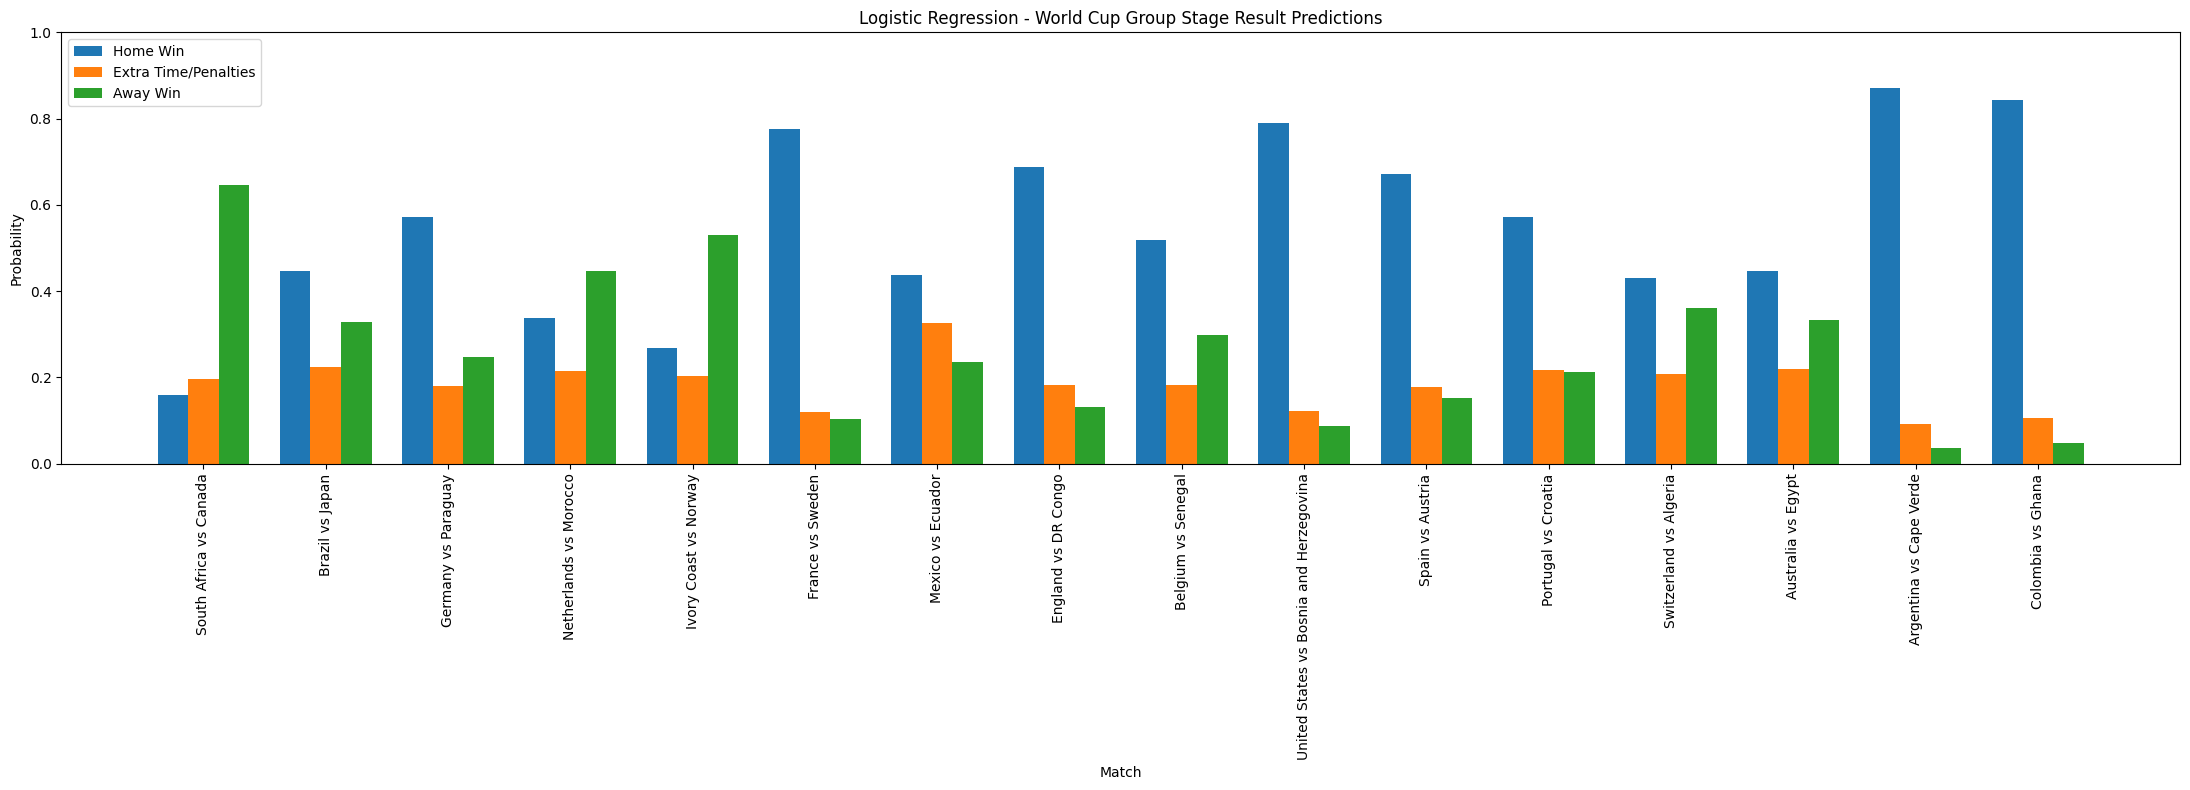

In [73]:
knockout_plot_probs(r32_predictions, model="Logistic Regression")

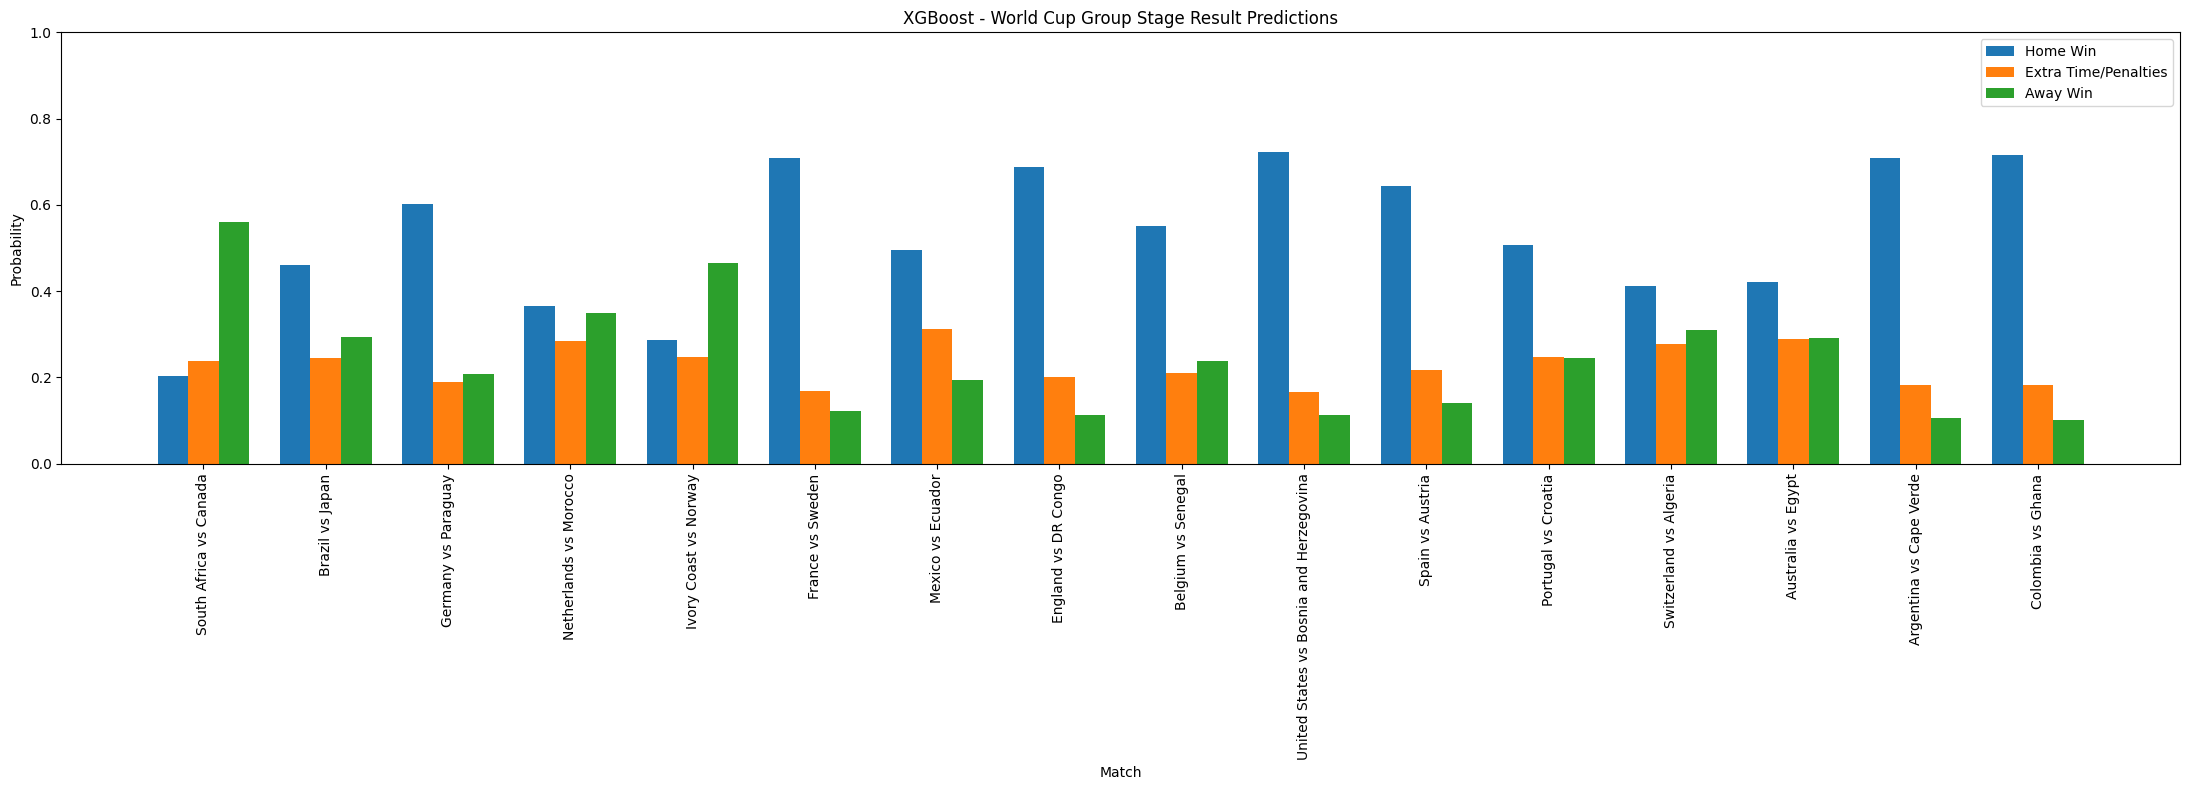

In [74]:
knockout_plot_probs(r32_predictions, model="XGBoost")


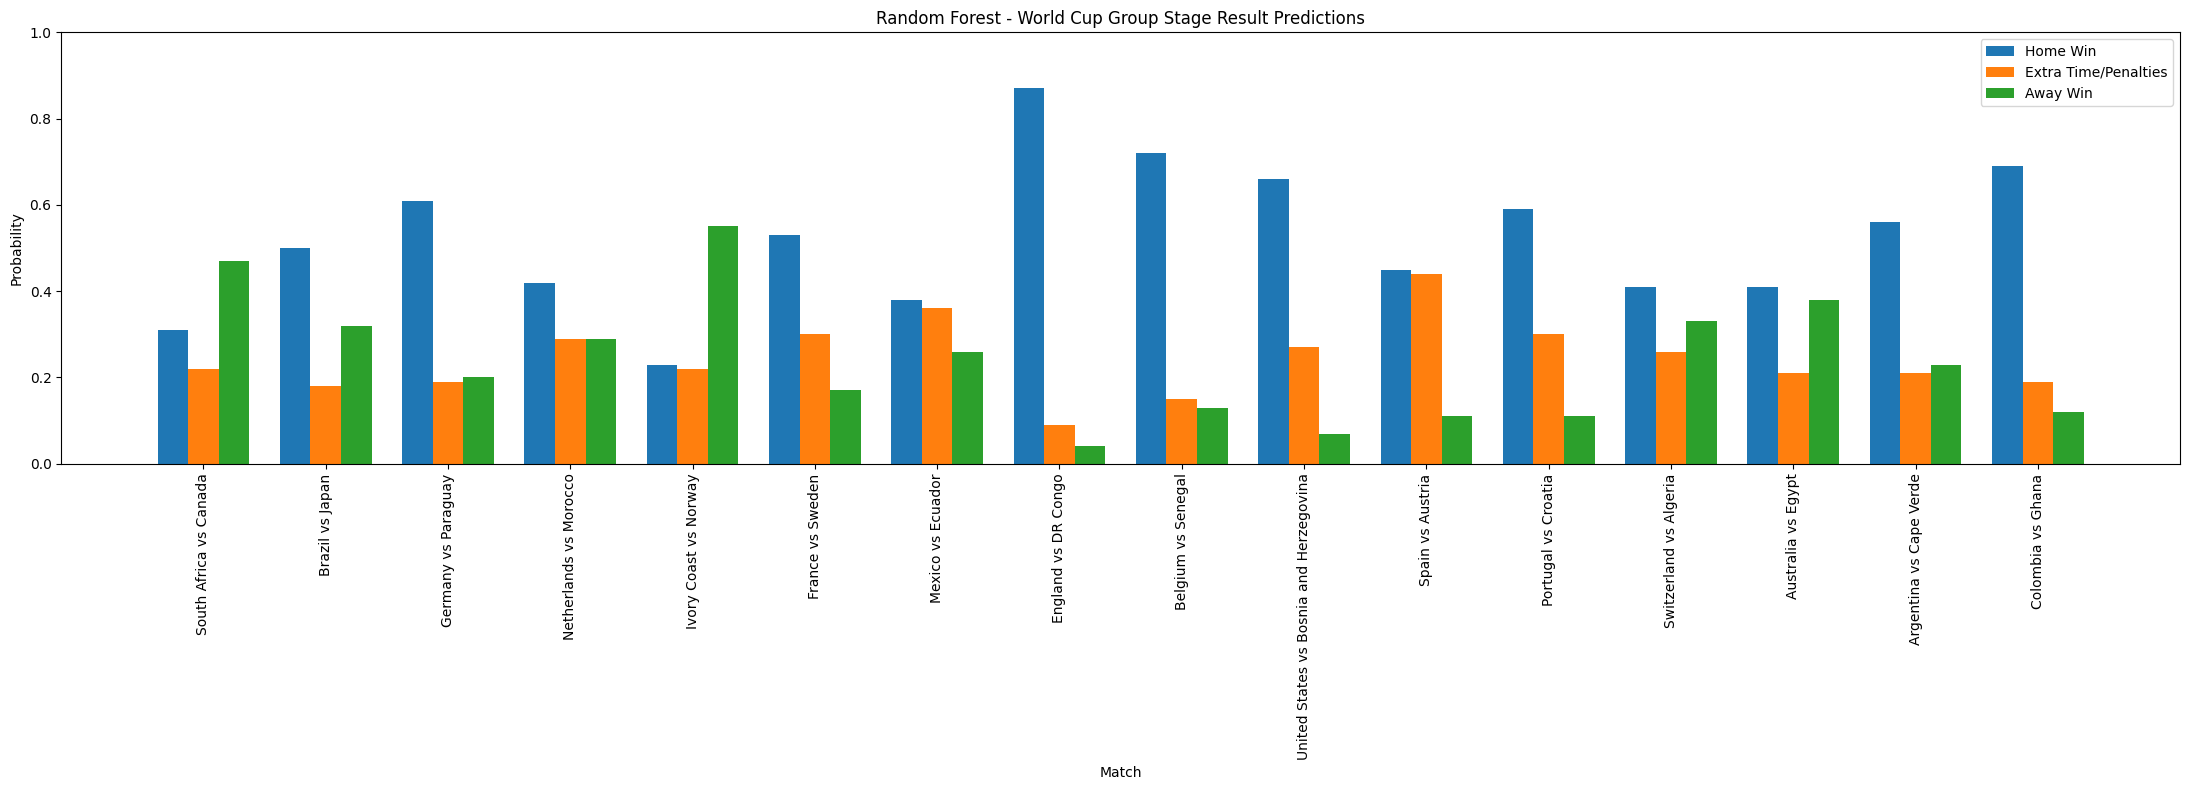

In [75]:
knockout_plot_probs(r32_predictions, model="Random Forest")


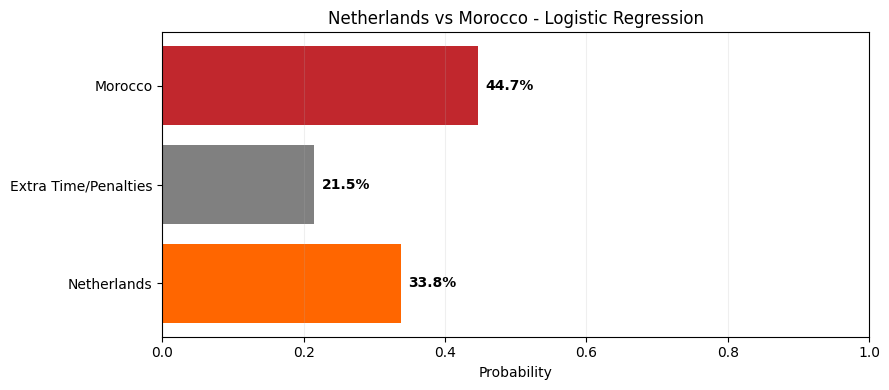

In [76]:
ko_plot_single_match_probs(
    r32_predictions,
    "Netherlands",
    "Morocco",
    model="Logistic Regression"
)

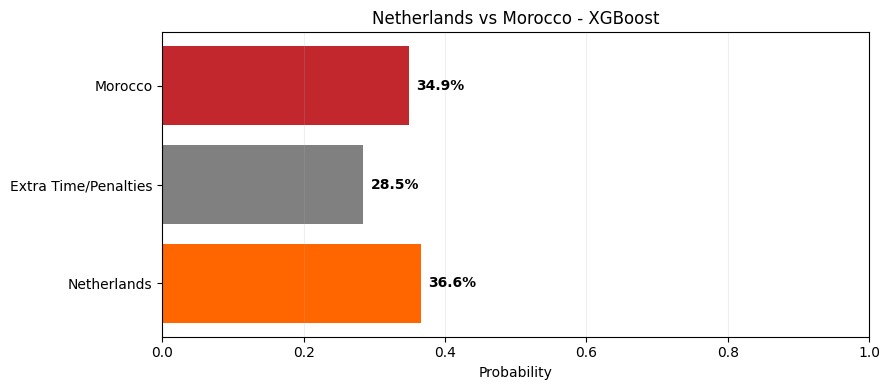

In [77]:
ko_plot_single_match_probs(
    r32_predictions,
    "Netherlands",
    "Morocco",
    model="XGBoost"
)

In [78]:
r32_features.to_csv(
    "r32_features.csv",
    index=False
)

In [79]:
r32_actual_results = pd.DataFrame([
    {"home_team": "South Africa", "away_team": "Canada",
     "date": "2026-06-28", "home_score": 0, "away_score": 1, "result": "A"},

    {"home_team": "Brazil", "away_team": "Japan",
     "date": "2026-06-29", "home_score": 2, "away_score": 1, "result": "H"},

    {"home_team": "Germany", "away_team": "Paraguay",
     "date": "2026-06-29", "home_score": 1, "away_score": 1, "result": "A"},

    {"home_team": "Netherlands", "away_team": "Morocco",
     "date": "2026-06-29", "home_score": 1, "away_score": 1, "result": "A"},

    {"home_team": "Ivory Coast", "away_team": "Norway",
     "date": "2026-06-30", "home_score": 1, "away_score": 2, "result": "A"},

    {"home_team": "France", "away_team": "Sweden",
     "date": "2026-06-30", "home_score": 3, "away_score": 0, "result": "H"},

    {"home_team": "Mexico", "away_team": "Ecuador",
     "date": "2026-06-30", "home_score": 2, "away_score": 0, "result": "H"},

    {"home_team": "England", "away_team": "DR Congo",
     "date": "2026-07-01", "home_score": 2, "away_score": 1, "result": "H"},

    {"home_team": "Belgium", "away_team": "Senegal",
     "date": "2026-07-01", "home_score": 3, "away_score": 2, "result": "H"},

    {"home_team": "United States", "away_team": "Bosnia and Herzegovina",
     "date": "2026-07-01", "home_score": 2, "away_score": 0, "result": "H"},

    {"home_team": "Spain", "away_team": "Austria",
     "date": "2026-07-02", "home_score": 3, "away_score": 0, "result": "H"},

    {"home_team": "Portugal", "away_team": "Croatia",
     "date": "2026-07-02", "home_score": 2, "away_score": 1, "result": "H"},

    {"home_team": "Switzerland", "away_team": "Algeria",
     "date": "2026-07-02", "home_score": 2, "away_score": 0, "result": "H"},

    {"home_team": "Argentina", "away_team": "Cape Verde",
     "date": "2026-07-03", "home_score": 3, "away_score": 2, "result": "H"},

    {"home_team": "Colombia", "away_team": "Ghana",
     "date": "2026-07-03", "home_score": 1, "away_score": 0, "result": "H"},

    {"home_team": "Australia", "away_team": "Egypt",
     "date": "2026-07-03", "home_score": 1, "away_score": 1, "result": "A"},
])

r32_actual_results["date"] = pd.to_datetime(r32_actual_results["date"])

In [80]:
r32_actual_results = r32_actual_results.rename(
    columns={"result": "actual_result"}
)

In [81]:
r32_actual_results.to_csv("r32_actual_results.csv")

In [82]:
correct_r32_predictions, wrong_r32_predictions = check_predictions(
    r32_predictions,
    r32_actual_results
)
wrong_r32_predictions

Total matches evaluated: 16

Accuracy:
Logistic Regression: 14/16 (87.50%)
Random Forest: 13/16 (81.25%)
XGBoost: 13/16 (81.25%)

Correct Predictions:

--- Logistic Regression ---
South Africa vs Canada: prediction: Canada, actual: Canada
Brazil vs Japan: prediction: Brazil, actual: Brazil
Netherlands vs Morocco: prediction: Morocco, actual: Morocco
Ivory Coast vs Norway: prediction: Norway, actual: Norway
France vs Sweden: prediction: France, actual: France
Mexico vs Ecuador: prediction: Mexico, actual: Mexico
England vs DR Congo: prediction: England, actual: England
Belgium vs Senegal: prediction: Belgium, actual: Belgium
United States vs Bosnia and Herzegovina: prediction: United States, actual: United States
Spain vs Austria: prediction: Spain, actual: Spain
Portugal vs Croatia: prediction: Portugal, actual: Portugal
Switzerland vs Algeria: prediction: Switzerland, actual: Switzerland
Argentina vs Cape Verde: prediction: Argentina, actual: Argentina
Colombia vs Ghana: prediction: C

{'Logistic Regression': ['Germany vs Paraguay: prediction: Germany, actual: Paraguay',
  'Australia vs Egypt: prediction: Australia, actual: Egypt'],
 'Random Forest': ['Germany vs Paraguay: prediction: Germany, actual: Paraguay',
  'Netherlands vs Morocco: prediction: Netherlands, actual: Morocco',
  'Australia vs Egypt: prediction: Australia, actual: Egypt'],
 'XGBoost': ['Germany vs Paraguay: prediction: Germany, actual: Paraguay',
  'Netherlands vs Morocco: prediction: Netherlands, actual: Morocco',
  'Australia vs Egypt: prediction: Australia, actual: Egypt']}

In [83]:
def get_wrong_predictions(predictions, actual_results):

    actual = actual_results[
        ["home_team", "away_team", "actual_result"]
    ]

    comparison = predictions.merge(
        actual,
        on=["home_team", "away_team"],
        how="left"
    )

    wrong_lr = comparison[
        comparison["lr_prediction"] != comparison["actual_result"]
    ][
        ["home_team", "away_team",
         "lr_prediction", "actual_result"]
    ]

    wrong_rf = comparison[
        comparison["rf_prediction"] != comparison["actual_result"]
    ][
        ["home_team", "away_team",
         "rf_prediction", "actual_result"]
    ]

    wrong_xgb = comparison[
        comparison["xgb_prediction"] != comparison["actual_result"]
    ][
        ["home_team", "away_team",
         "xgb_prediction", "actual_result"]
    ]

    return wrong_lr, wrong_rf, wrong_xgb

In [84]:
wrong_lr, wrong_rf, wrong_xgb = get_wrong_predictions(
    r32_predictions,
    r32_actual_results
)
wrong_xgb

,home_team,away_team,xgb_prediction,actual_result
2,Germany,Paraguay,H,A
3,Netherlands,Morocco,H,A
13,Australia,Egypt,H,A


In [85]:
# post_r32_df, post_r32_elo = update_tournament_state(
#     post_gs_df,
#     r32_actual_results
# )
post_r32_df=pd.read_csv("post_r32_df.csv")
post_r32_elo=pd.read_csv("post_r32_elo.csv")

In [86]:
r16_fixtures = pd.DataFrame([
    {
        "home_team": "Canada",
        "away_team": "Morocco",
        "date": "2026-07-04",
        "neutral": 1
    },
    {
        "home_team": "Paraguay",
        "away_team": "France",
        "date": "2026-07-04",
        "neutral": 1
    },
    {
        "home_team": "Brazil",
        "away_team": "Norway",
        "date": "2026-07-05",
        "neutral": 1
    },
    {
        "home_team": "Mexico",
        "away_team": "England",
        "date": "2026-07-05",
        "neutral": 0
    },
    {
        "home_team": "Portugal",
        "away_team": "Spain",
        "date": "2026-07-06",
        "neutral": 1
    },
    {
        "home_team": "United States",
        "away_team": "Belgium",
        "date": "2026-07-06",
        "neutral": 1
    },
    {
        "home_team": "Argentina",
        "away_team": "Egypt",
        "date": "2026-07-07",
        "neutral": 1
    },
    {
        "home_team": "Switzerland",
        "away_team": "Colombia",
        "date": "2026-07-07",
        "neutral": 1
    }
])

In [87]:
post_r32_df["date"] = pd.to_datetime(post_r32_df["date"])
r16_fixtures["date"] = pd.to_datetime(r16_fixtures["date"])

In [88]:
post_r32_elo_df = pd.read_csv("post_r32_elo.csv")

post_r32_elo = dict(
    zip(
        post_r32_elo_df["team"],
        post_r32_elo_df["elo"]
    )
)

In [89]:
r16_features = prepare_round_features(
    r16_fixtures,
    post_r32_df,
    post_r32_elo
)
r16_features

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,tournament_weight,elo_home,elo_away,elo_diff
0,Canada,Morocco,2026-07-04,1,FIFA World Cup,1.6,0.6,1.0,0.4,0.5,...,1.6,0.7,0.3,0,1,0,5,1318.056422,1453.681467,-135.625044
1,Paraguay,France,2026-07-04,1,FIFA World Cup,1.2,1.2,0.0,0.5,0.1,...,2.1,0.9,0.0,0,0,0,5,1321.060339,1519.822256,-198.761917
2,Brazil,Norway,2026-07-05,1,FIFA World Cup,2.4,0.9,1.5,0.7,0.2,...,0.9,0.6,0.2,0,0,0,5,1479.381202,1385.927424,93.453779
3,Mexico,England,2026-07-05,0,FIFA World Cup,2.1,0.2,1.9,0.8,0.2,...,1.2,0.7,0.2,0,0,0,5,1442.345590,1458.093286,-15.747697
4,Portugal,Spain,2026-07-06,1,FIFA World Cup,2.3,0.7,1.6,0.6,0.3,...,1.7,0.6,0.4,0,1,2,5,1461.537688,1538.382331,-76.844643
5,United States,Belgium,2026-07-06,1,FIFA World Cup,2.3,1.7,0.6,0.6,0.0,...,2.2,0.6,0.4,0,1,0,5,1353.355369,1386.597842,-33.242474
6,Argentina,Egypt,2026-07-07,1,FIFA World Cup,3.1,0.4,2.7,1.0,0.0,...,0.5,0.4,0.4,0,0,0,5,1581.435677,1296.238758,285.196920
7,Switzerland,Colombia,2026-07-07,1,FIFA World Cup,2.2,1.1,1.1,0.5,0.4,...,0.9,0.7,0.1,0,0,0,5,1384.491199,1462.418327,-77.927128


In [90]:
r16_predictions = predict_ko_matches(
    models,
    r16_features,
    features,
    scaler
)
r16_predictions

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,Canada,Morocco,2026-07-04,1,FIFA World Cup,1.6,0.6,1.0,0.4,0.5,...,0.200309,0.39,0.28,0.33,0.486801,0.245136,0.268063,A,A,A
1,Paraguay,France,2026-07-04,1,FIFA World Cup,1.2,1.2,0.0,0.5,0.1,...,0.131179,0.58,0.18,0.24,0.592630,0.219240,0.188130,A,A,A
2,Brazil,Norway,2026-07-05,1,FIFA World Cup,2.4,0.9,1.5,0.7,0.2,...,0.537103,0.12,0.28,0.60,0.261566,0.216386,0.522048,H,H,H
3,Mexico,England,2026-07-05,0,FIFA World Cup,2.1,0.2,1.9,0.8,0.2,...,0.455798,0.31,0.27,0.42,0.276112,0.304353,0.419535,H,H,H
4,Portugal,Spain,2026-07-06,1,FIFA World Cup,2.3,0.7,1.6,0.6,0.3,...,0.198377,0.33,0.39,0.28,0.401937,0.310098,0.287965,A,A,A
5,United States,Belgium,2026-07-06,1,FIFA World Cup,2.3,1.7,0.6,0.6,0.0,...,0.268673,0.39,0.20,0.41,0.452449,0.249149,0.298401,A,H,A
6,Argentina,Egypt,2026-07-07,1,FIFA World Cup,3.1,0.4,2.7,1.0,0.0,...,0.753766,0.18,0.12,0.70,0.142554,0.200794,0.656652,H,H,H
7,Switzerland,Colombia,2026-07-07,1,FIFA World Cup,2.2,1.1,1.1,0.5,0.4,...,0.268365,0.40,0.28,0.32,0.428633,0.264847,0.306520,A,A,A


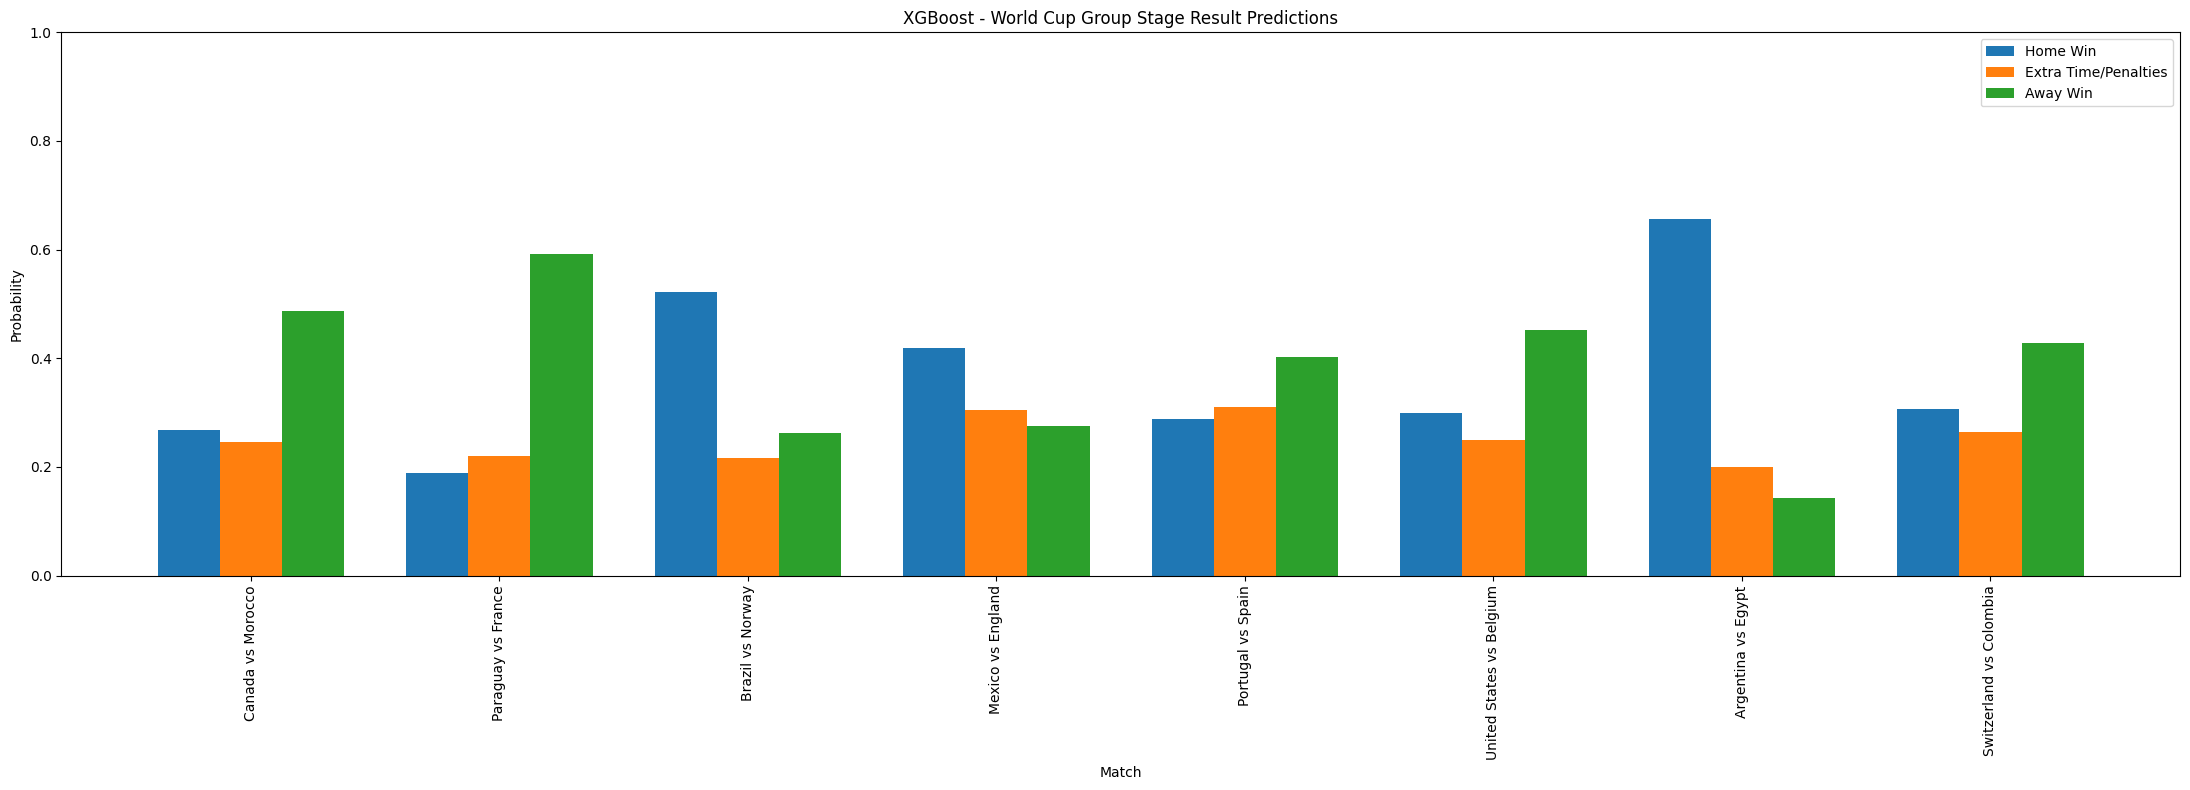

In [91]:
knockout_plot_probs(r16_predictions)

In [92]:
r16_predictions[
    [
        "home_team",
        "away_team",
        "lr_prediction",
        "rf_prediction",
        "xgb_prediction"
    ]
]

,home_team,away_team,lr_prediction,rf_prediction,xgb_prediction
0,Canada,Morocco,A,A,A
1,Paraguay,France,A,A,A
2,Brazil,Norway,H,H,H
3,Mexico,England,H,H,H
4,Portugal,Spain,A,A,A
5,United States,Belgium,A,H,A
6,Argentina,Egypt,H,H,H
7,Switzerland,Colombia,A,A,A


In [93]:
# ko_plot_single_match_probs()

In [94]:
r16_actual_results = pd.DataFrame([
    ["2026-07-04", "Canada", "Morocco", 0, 3, "A"],
    ["2026-07-04", "Paraguay", "France", 0, 1, "A"],
    ["2026-07-05", "Brazil", "Norway", 1, 2, "A"],
    ["2026-07-05", "Mexico", "England", 2, 3, "A"],
    ["2026-07-06", "Portugal", "Spain", 0, 1, "A"],
    ["2026-07-06", "United States", "Belgium", 1, 4, "A"],
    ["2026-07-07", "Argentina", "Egypt", 3, 2, "H"],
    ["2026-07-07", "Switzerland", "Colombia", 0, 0, "H"],
], columns=[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "actual_result"
])

In [95]:
check_predictions(r16_predictions,r16_actual_results)
wrong_lr, wrong_rf, wrong_xgb = get_wrong_predictions(
    r16_predictions,
    r16_actual_results
)
wrong_rf

Total matches evaluated: 8

Accuracy:
Logistic Regression: 5/8 (62.50%)
Random Forest: 4/8 (50.00%)
XGBoost: 5/8 (62.50%)

Correct Predictions:

--- Logistic Regression ---
Canada vs Morocco: prediction: Morocco, actual: Morocco
Paraguay vs France: prediction: France, actual: France
Portugal vs Spain: prediction: Spain, actual: Spain
United States vs Belgium: prediction: Belgium, actual: Belgium
Argentina vs Egypt: prediction: Argentina, actual: Argentina

--- Random Forest ---
Canada vs Morocco: prediction: Morocco, actual: Morocco
Paraguay vs France: prediction: France, actual: France
Portugal vs Spain: prediction: Spain, actual: Spain
Argentina vs Egypt: prediction: Argentina, actual: Argentina

--- XGBoost ---
Canada vs Morocco: prediction: Morocco, actual: Morocco
Paraguay vs France: prediction: France, actual: France
Portugal vs Spain: prediction: Spain, actual: Spain
United States vs Belgium: prediction: Belgium, actual: Belgium
Argentina vs Egypt: prediction: Argentina, actual:

,home_team,away_team,rf_prediction,actual_result
2,Brazil,Norway,H,A
3,Mexico,England,H,A
5,United States,Belgium,H,A
7,Switzerland,Colombia,A,H


In [96]:
# post_r16_df, post_r16_elo = update_tournament_state(
#     post_r32_df,
#     r16_actual_results
# )

In [97]:
post_r16_df=pd.read_csv("post_r16_df.csv")
# pd.DataFrame(
#     post_r16_elo.items(),
#     columns=["team", "elo"]
# ).sort_values(
#     "elo",
#     ascending=False
# ).to_csv(
#     "post_r16_elo.csv",
#     index=False
# )
# post_r16_elo=pd.read_csv("post_r16_elo.csv")

In [98]:
qf_fixtures = pd.DataFrame([
    {
        "home_team": "France",
        "away_team": "Morocco",
        "date": "2026-07-09",
        "neutral": 1
    },
    {
        "home_team": "Spain",
        "away_team": "Belgium",
        "date": "2026-07-10",
        "neutral": 1
    },
    {
        "home_team": "Norway",
        "away_team": "England",
        "date": "2026-07-11",
        "neutral": 1
    },
    {
        "home_team": "Argentina",
        "away_team": "Switzerland",
        "date": "2026-07-11",
        "neutral": 1
    }
])

In [99]:
post_r16_elo_df = pd.read_csv("post_r16_elo.csv")

post_r16_elo = dict(
    zip(
        post_r16_elo_df["team"],
        post_r16_elo_df["elo"]
    )
)

In [100]:
post_r16_df["date"] = pd.to_datetime(post_r16_df["date"])
qf_fixtures["date"] = pd.to_datetime(qf_fixtures["date"])

In [101]:
qf_features = prepare_round_features(
    qf_fixtures,
    post_r16_df,
    post_r16_elo
)
qf_features.to_csv("qf_features.csv",index=False)

In [102]:
qf_features[features]

,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,neutral,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff,home_draw_rate,away_draw_rate,home_goal_diff,away_goal_diff
0,2.6,0.8,0.9,2.3,0.7,0.7,1,5,1,0,0,1527.551068,1468.758947,58.792120,0.0,0.3,1.8,1.6
1,1.8,0.4,0.6,3.3,0.8,0.7,1,5,0,0,0,1550.899563,1408.306945,142.592618,0.4,0.3,1.4,2.5
2,2.1,1.4,0.6,1.8,0.7,0.7,1,5,0,0,0,1406.128193,1473.366856,-67.238663,0.2,0.2,0.7,1.1
3,2.8,0.6,1.0,1.8,1.0,0.5,1,5,0,0,0,1586.627296,1401.785139,184.842157,0.0,0.4,2.2,0.8


In [103]:
qf_predictions = predict_ko_matches(
    models,
    qf_features,
    features,
    scaler
)
qf_predictions

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,France,Morocco,2026-07-09,1,FIFA World Cup,2.6,0.8,1.8,0.9,0.0,...,0.445310,0.25,0.29,0.46,0.295489,0.235647,0.468864,H,H,H
1,Spain,Belgium,2026-07-10,1,FIFA World Cup,1.8,0.4,1.4,0.6,0.4,...,0.588319,0.27,0.35,0.38,0.215818,0.259839,0.524343,H,H,H
2,Norway,England,2026-07-11,1,FIFA World Cup,2.1,1.4,0.7,0.6,0.2,...,0.254465,0.38,0.25,0.37,0.448516,0.261362,0.290121,A,A,A
3,Argentina,Switzerland,2026-07-11,1,FIFA World Cup,2.8,0.6,2.2,1.0,0.0,...,0.619791,0.27,0.18,0.55,0.157830,0.209487,0.632684,H,H,H


In [104]:
qf_actual_results = pd.DataFrame([
    ["2026-07-09", "France", "Morocco", 2, 0, "H"],
    ["2026-07-10", "Spain", "Belgium", 2, 1, "H"],
    ["2026-07-11", "Norway", "England", 1, 2, "A"],
    ["2026-07-11", "Argentina", "Switzerland", 3, 1, "H"]
], columns=[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "actual_result"
])
qf_actual_results

,date,home_team,away_team,home_score,away_score,actual_result
0,2026-07-09,France,Morocco,2,0,H
1,2026-07-10,Spain,Belgium,2,1,H
2,2026-07-11,Norway,England,1,2,A
3,2026-07-11,Argentina,Switzerland,3,1,H


In [105]:
check_predictions(qf_predictions,qf_actual_results)

Total matches evaluated: 4

Accuracy:
Logistic Regression: 4/4 (100.00%)
Random Forest: 4/4 (100.00%)
XGBoost: 4/4 (100.00%)

Correct Predictions:

--- Logistic Regression ---
France vs Morocco: prediction: France, actual: France
Spain vs Belgium: prediction: Spain, actual: Spain
Norway vs England: prediction: England, actual: England
Argentina vs Switzerland: prediction: Argentina, actual: Argentina

--- Random Forest ---
France vs Morocco: prediction: France, actual: France
Spain vs Belgium: prediction: Spain, actual: Spain
Norway vs England: prediction: England, actual: England
Argentina vs Switzerland: prediction: Argentina, actual: Argentina

--- XGBoost ---
France vs Morocco: prediction: France, actual: France
Spain vs Belgium: prediction: Spain, actual: Spain
Norway vs England: prediction: England, actual: England
Argentina vs Switzerland: prediction: Argentina, actual: Argentina


({'Logistic Regression': ['France vs Morocco: prediction: France, actual: France',
   'Spain vs Belgium: prediction: Spain, actual: Spain',
   'Norway vs England: prediction: England, actual: England',
   'Argentina vs Switzerland: prediction: Argentina, actual: Argentina'],
  'Random Forest': ['France vs Morocco: prediction: France, actual: France',
   'Spain vs Belgium: prediction: Spain, actual: Spain',
   'Norway vs England: prediction: England, actual: England',
   'Argentina vs Switzerland: prediction: Argentina, actual: Argentina'],
  'XGBoost': ['France vs Morocco: prediction: France, actual: France',
   'Spain vs Belgium: prediction: Spain, actual: Spain',
   'Norway vs England: prediction: England, actual: England',
   'Argentina vs Switzerland: prediction: Argentina, actual: Argentina']},
 {'Logistic Regression': [], 'Random Forest': [], 'XGBoost': []})

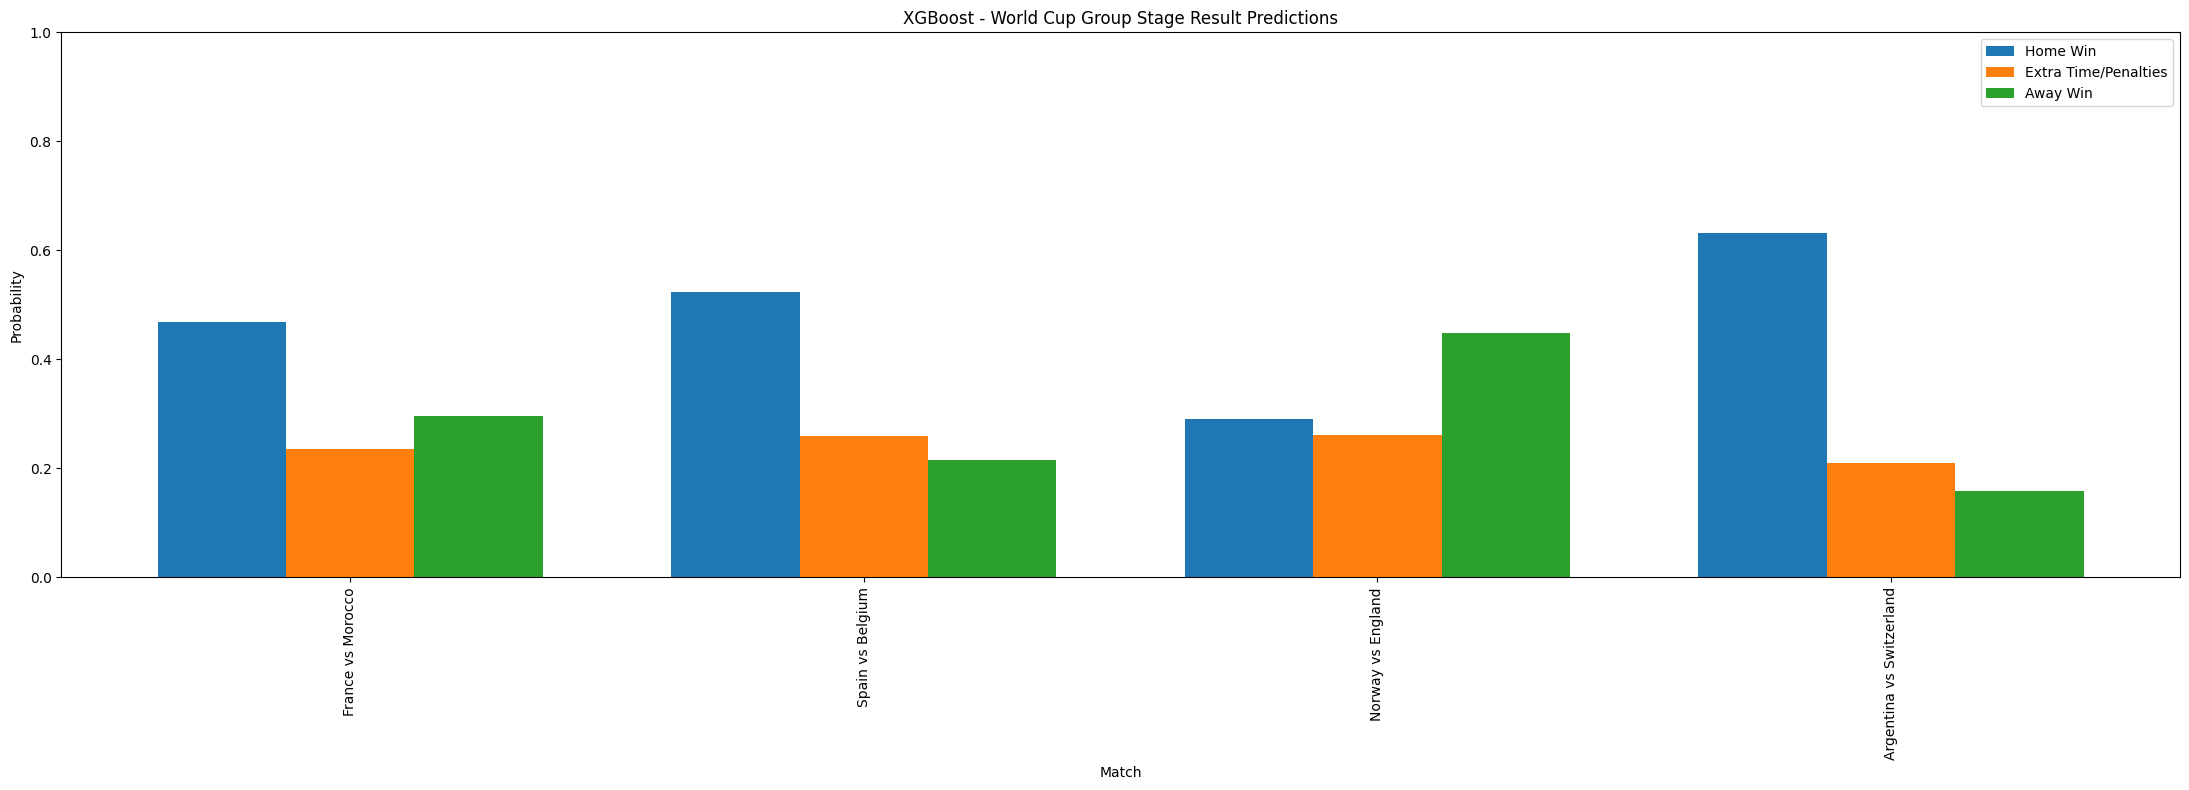

In [106]:
knockout_plot_probs(qf_predictions)

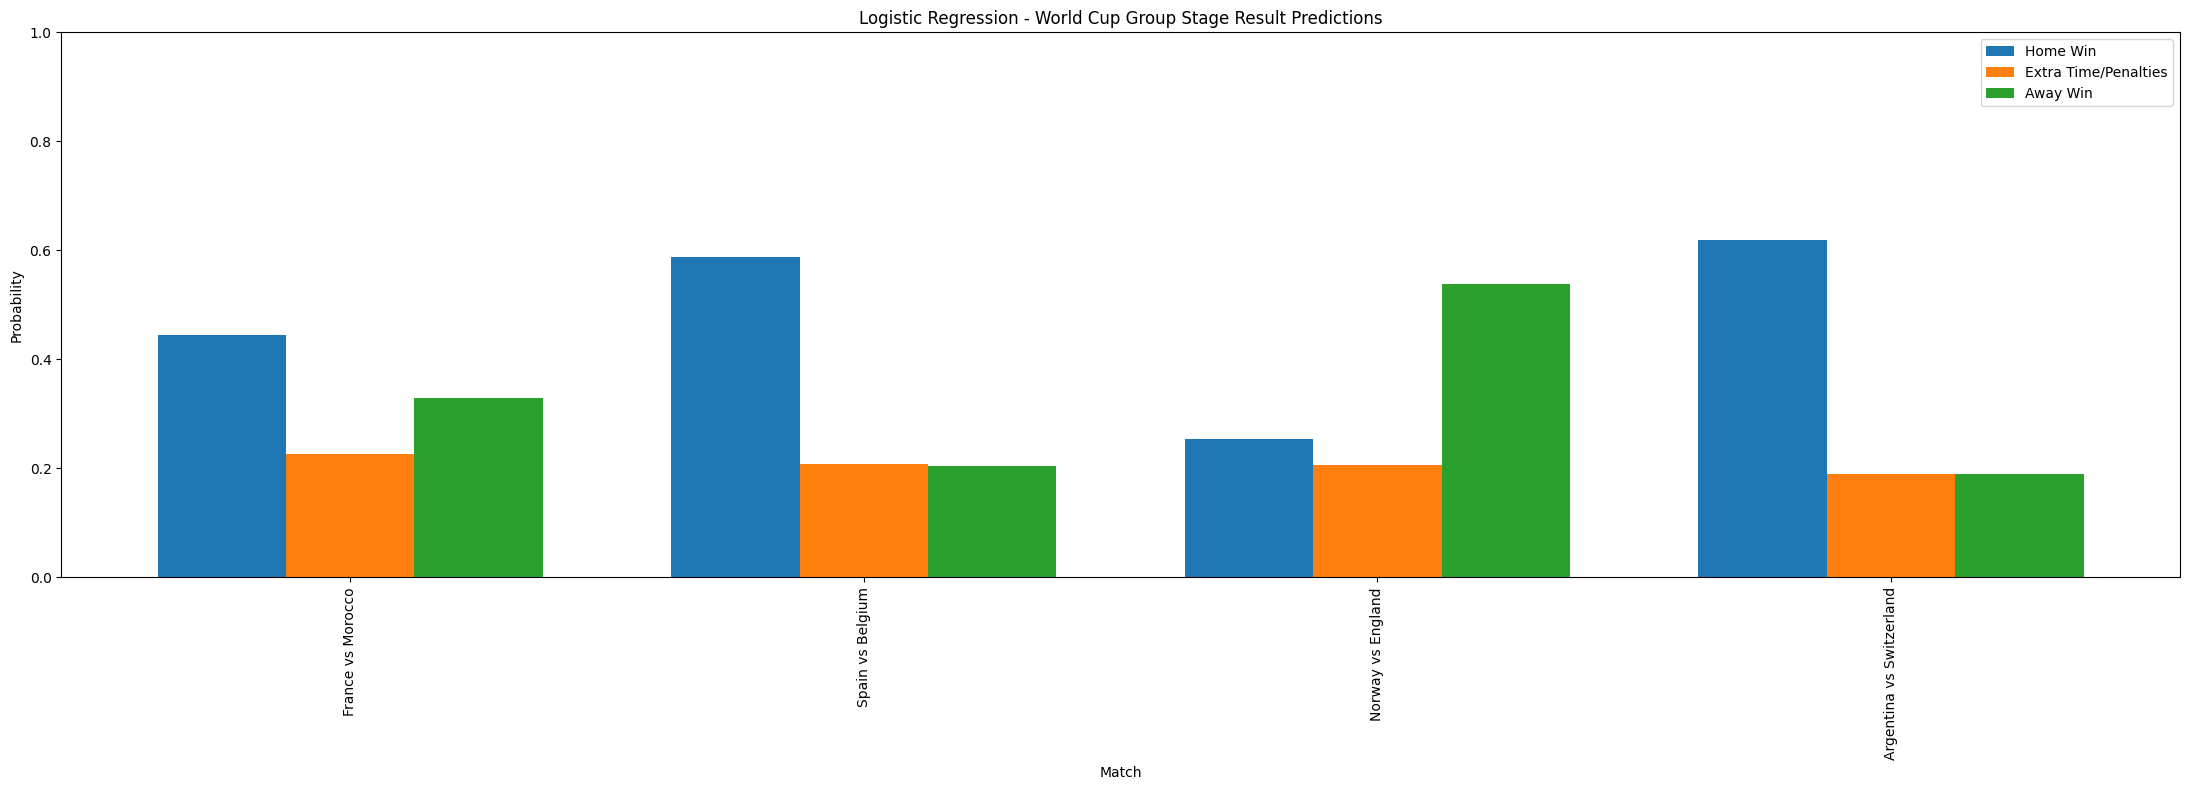

In [107]:
knockout_plot_probs(qf_predictions,"Logistic Regression")


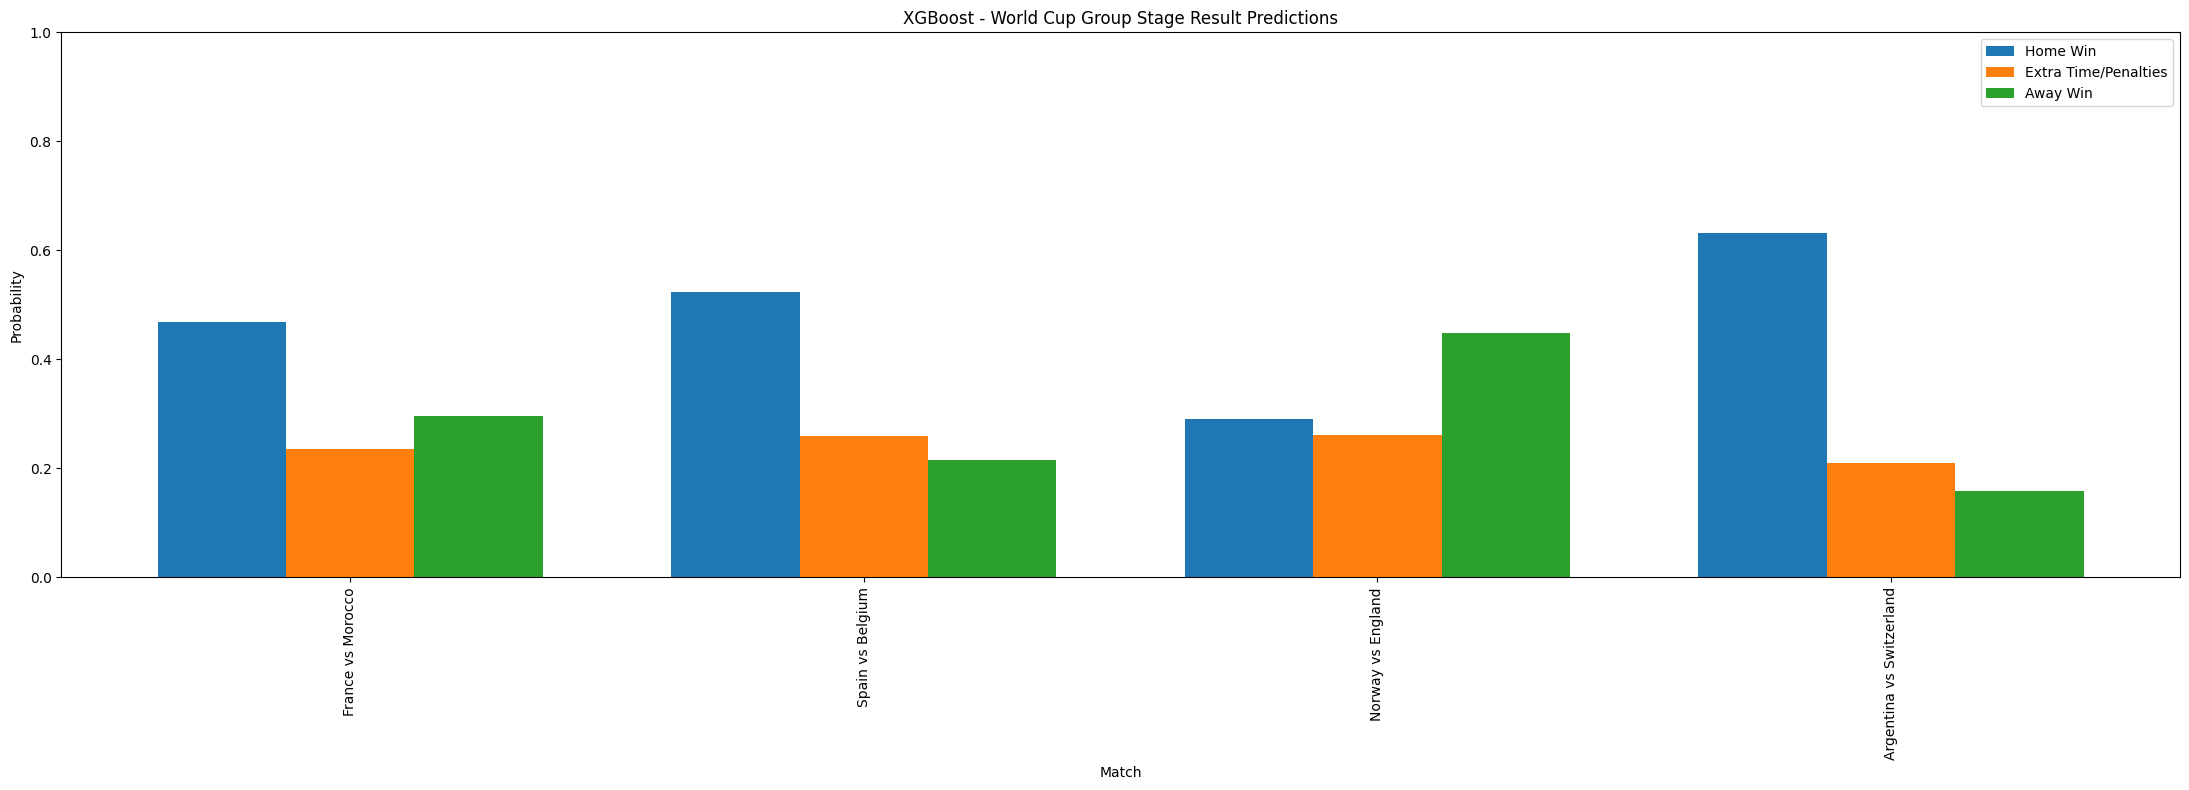

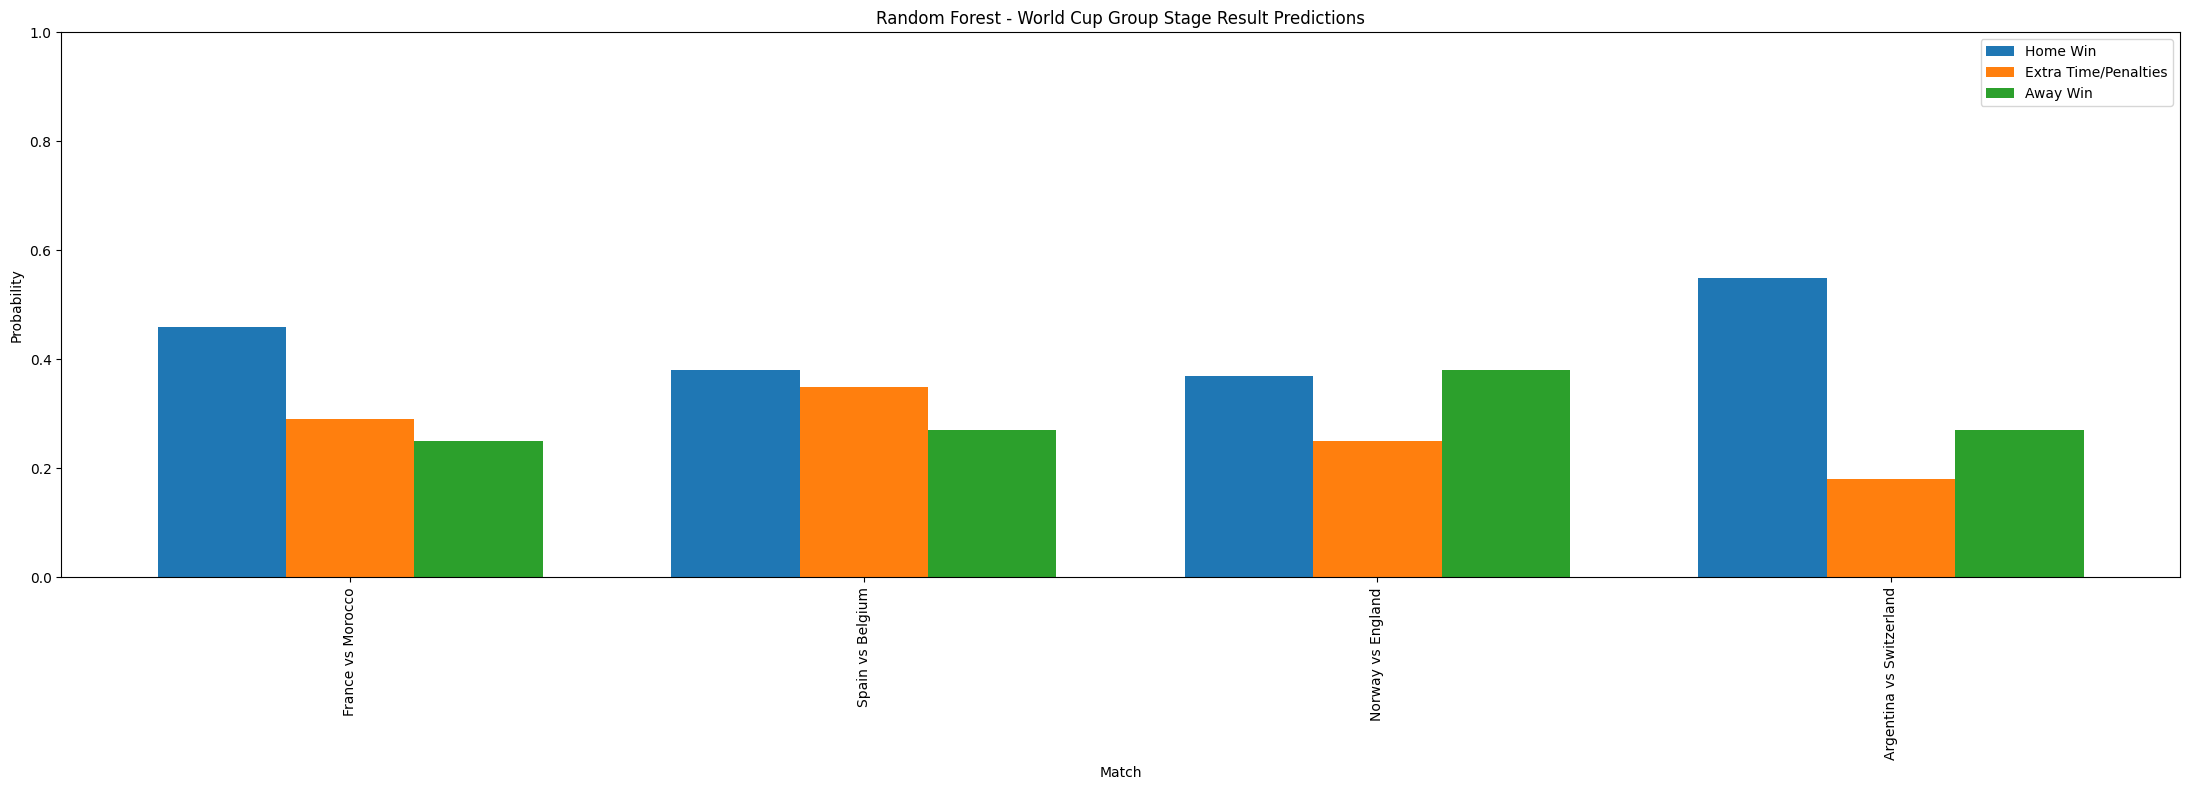

In [108]:
knockout_plot_probs(qf_predictions,"XGBoost")
knockout_plot_probs(qf_predictions,"Random Forest")


In [109]:
semi_fixtures = pd.DataFrame([
    {
        "date": "2026-07-14",
        "home_team": "France",
        "away_team": "Spain",
        "neutral": 1,
        "tournament": "FIFA World Cup"
    },
    {
        "date": "2026-07-15",
        "home_team": "England",
        "away_team": "Argentina",
        "neutral": 1,
        "tournament": "FIFA World Cup"
    }
])

In [110]:
# post_qf_df, post_qf_elo = update_tournament_state(
#     post_r16_df,
#    qf_actual_results)
post_qf_df=pd.read_csv("post_qf_df.csv")


post_qf_elo=pd.read_csv("post_qf_elo.csv")

In [111]:
post_qf_elo = dict(
    zip(
        post_qf_elo["team"],
        post_qf_elo["elo"]
    )
)

In [112]:
post_qf_df["date"] = pd.to_datetime(post_qf_df["date"])
semi_fixtures["date"] = pd.to_datetime(semi_fixtures["date"])

In [113]:
semi_features=prepare_round_features(semi_fixtures,post_qf_df,post_qf_elo)

In [114]:
# semi_features.to_csv("semi_features.csv",index=False)
semi_predictions = predict_ko_matches(
    models,
    semi_features,
    features,
    scaler
)
semi_predictions

,date,home_team,away_team,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,2026-07-14,France,Spain,1,FIFA World Cup,2.5,0.7,1.8,0.9,0.0,...,0.289498,0.33,0.32,0.35,0.350622,0.292992,0.356386,A,H,H
1,2026-07-15,England,Argentina,1,FIFA World Cup,1.8,0.8,1.0,0.7,0.2,...,0.215843,0.44,0.31,0.25,0.459083,0.268151,0.272767,A,A,A


In [115]:
semi_actual_results = pd.DataFrame([
    ["2026-07-14", "France", "Spain", 0, 2, "A"],
    ["2026-07-15", "England", "Argentina", 1, 2, "A"]
], columns=[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "actual_result"
])

semi_actual_results["tournament"] = "FIFA World Cup"

In [116]:
correct_semi_predictions, wrong_semi_predictions = check_predictions(
    semi_predictions,
    semi_actual_results
)

Total matches evaluated: 2

Accuracy:
Logistic Regression: 2/2 (100.00%)
Random Forest: 1/2 (50.00%)
XGBoost: 1/2 (50.00%)

Correct Predictions:

--- Logistic Regression ---
France vs Spain: prediction: Spain, actual: Spain
England vs Argentina: prediction: Argentina, actual: Argentina

--- Random Forest ---
England vs Argentina: prediction: Argentina, actual: Argentina

--- XGBoost ---
England vs Argentina: prediction: Argentina, actual: Argentina


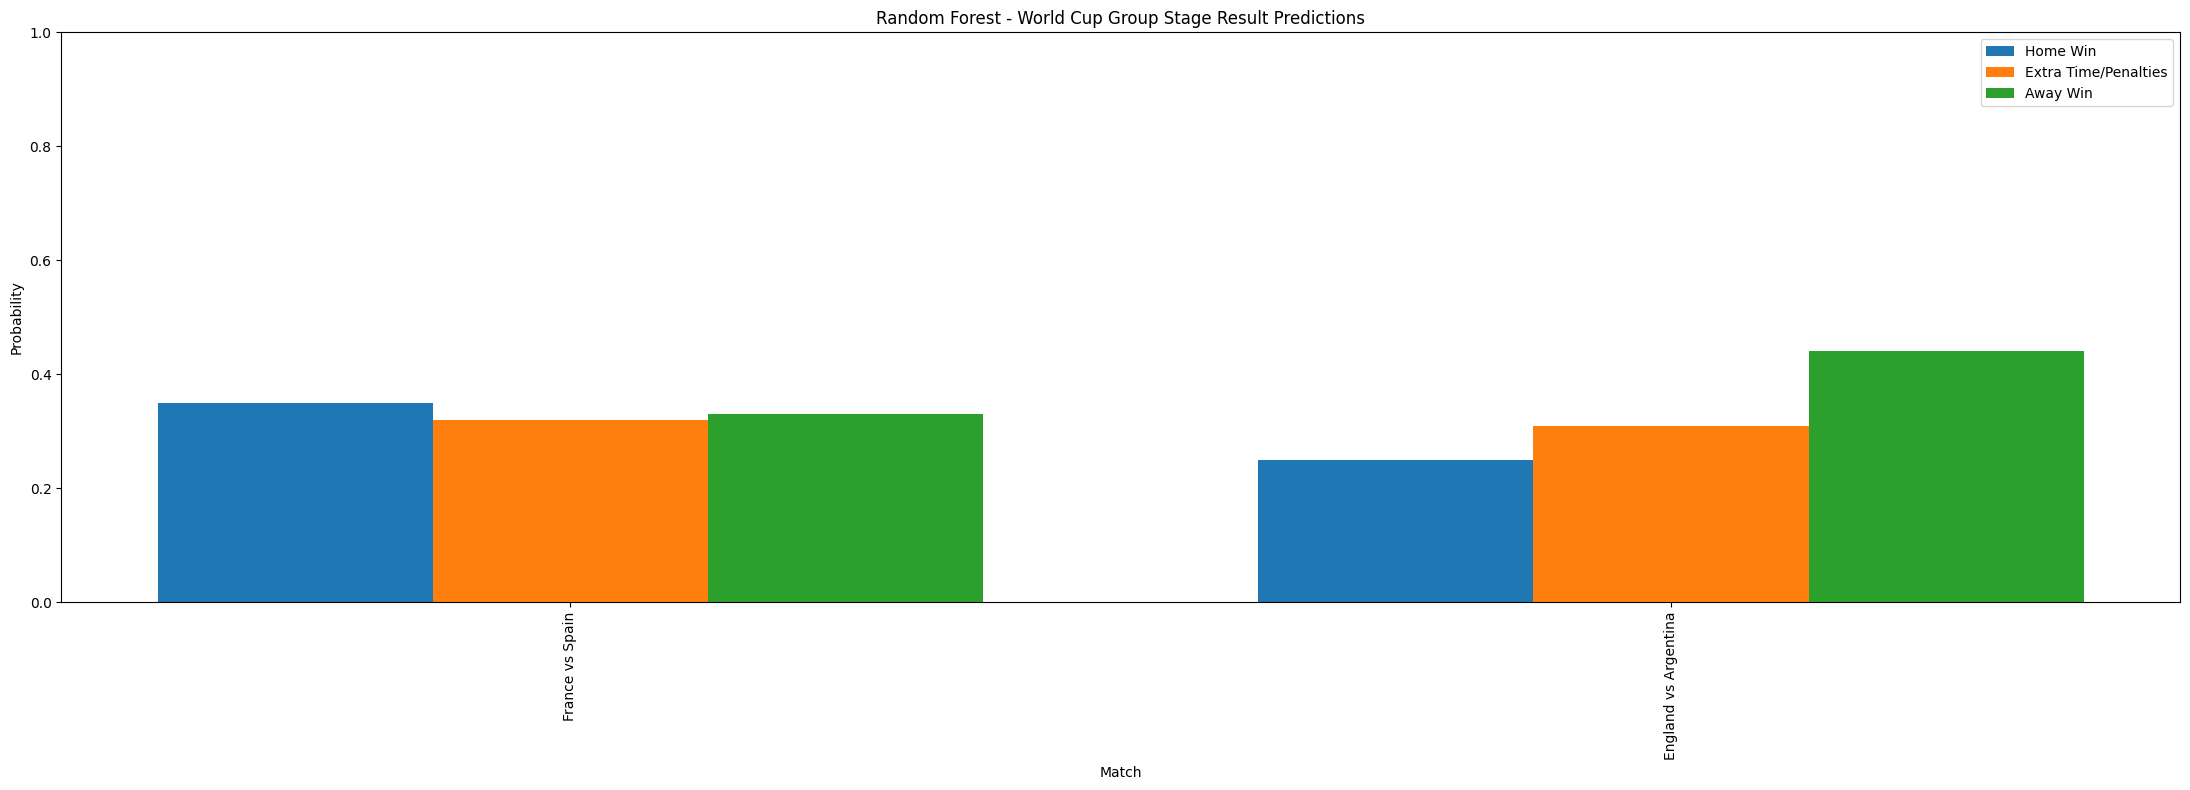

In [117]:
knockout_plot_probs(semi_predictions,"Random Forest")

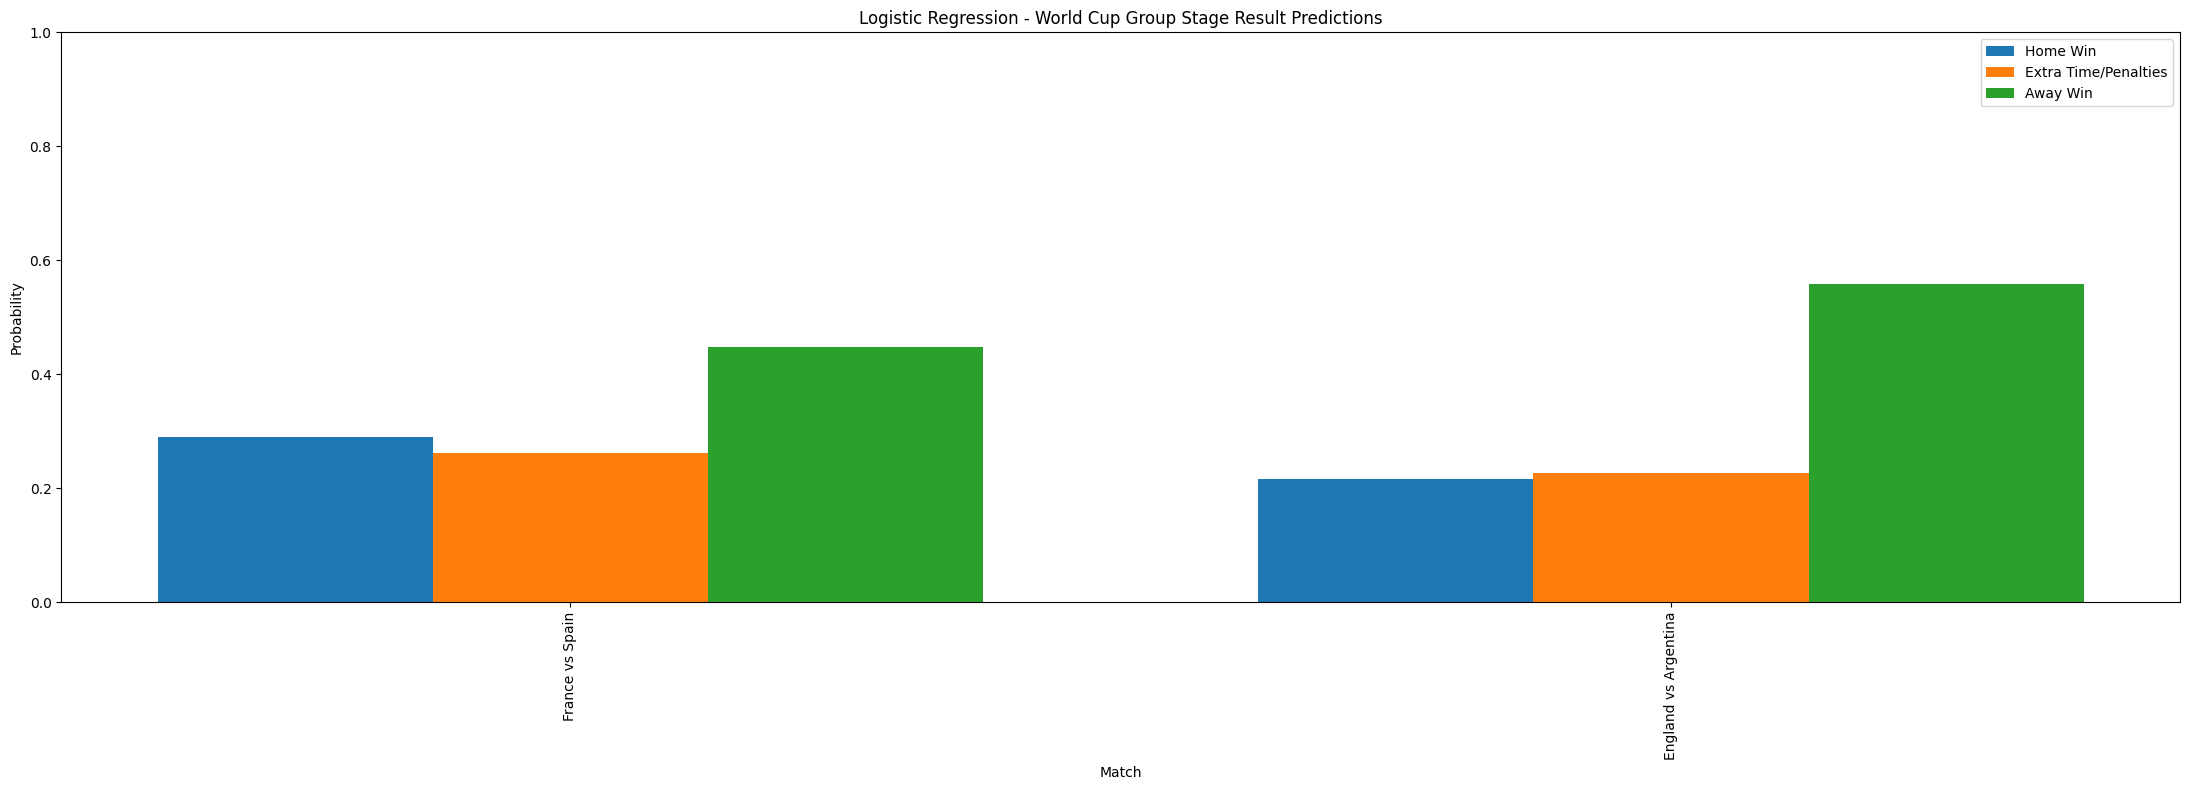

In [118]:
knockout_plot_probs(semi_predictions,"Logistic Regression")

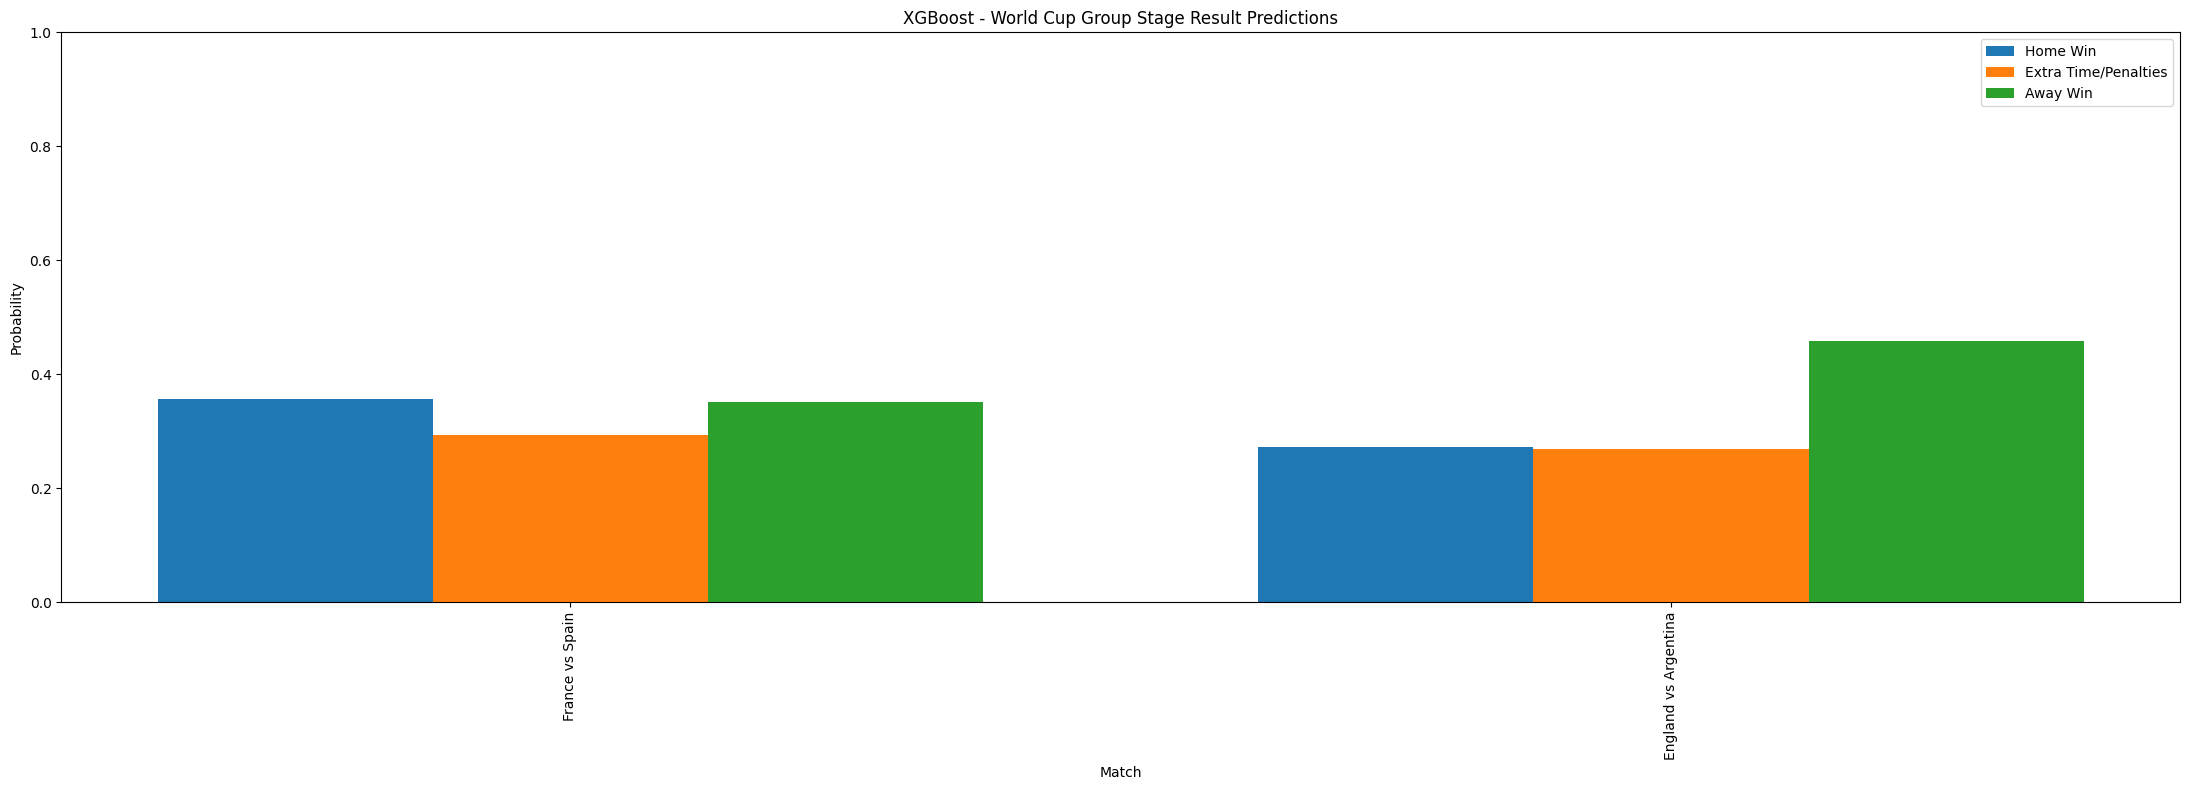

In [119]:
knockout_plot_probs(semi_predictions,"XGBoost")


In [120]:
final_fixtures = pd.DataFrame([
    {
        "date": "2026-07-19",
        "home_team": "Argentina",
        "away_team": "Spain",
        "neutral": 1,
        "tournament": "FIFA World Cup"
    }
])

In [121]:
# post_semi_df, post_semi_elo = update_tournament_state(
#     post_qf_df,
#     semi_actual_results
# )


In [122]:
# Reload tournament state
post_semi_df = pd.read_csv("post_semi_df.csv")
post_semi_elo_df = pd.read_csv("post_semi_elo.csv")

post_semi_df["date"] = pd.to_datetime(post_semi_df["date"])

post_semi_elo = dict(
    zip(
        post_semi_elo_df["team"],
        post_semi_elo_df["elo"]
    )
)

In [123]:
# post_semi_df=pd.read_csv("post_semi_df.csv")
# post_semi_elo_df = pd.read_csv("post_semi_elo.csv")

In [124]:
post_semi_df["date"] = pd.to_datetime(post_semi_df["date"])
final_fixtures["date"] = pd.to_datetime(final_fixtures["date"])

In [125]:
final_features = prepare_round_features(
    final_fixtures,
    post_semi_df,
    post_semi_elo
) 
final_features.to_csv("final_features.csv")

In [126]:
final_predictions = predict_ko_matches(
    models,
    final_features,
    features,
    scaler
)
final_predictions

,date,home_team,away_team,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,2026-07-19,Argentina,Spain,1,FIFA World Cup,2.9,0.7,2.2,1.0,0.0,...,0.345645,0.33,0.35,0.32,0.295022,0.286633,0.418345,A,A,H


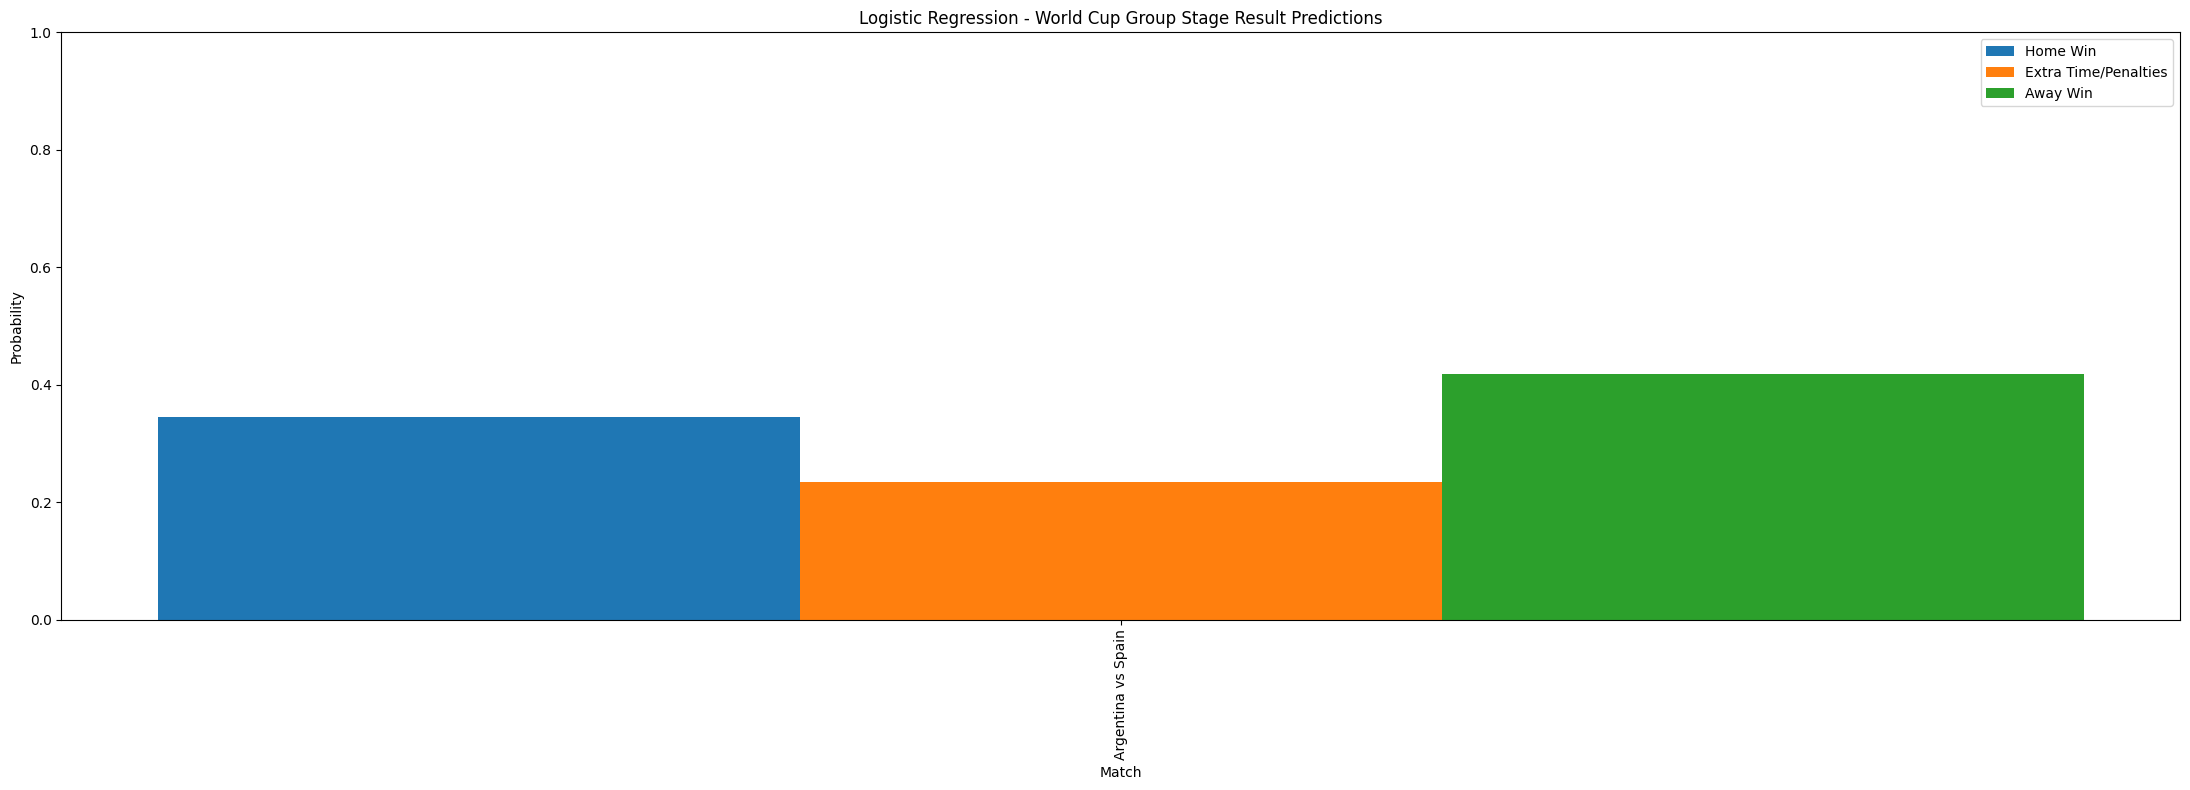

In [127]:
knockout_plot_probs(final_predictions,"Logistic Regression")

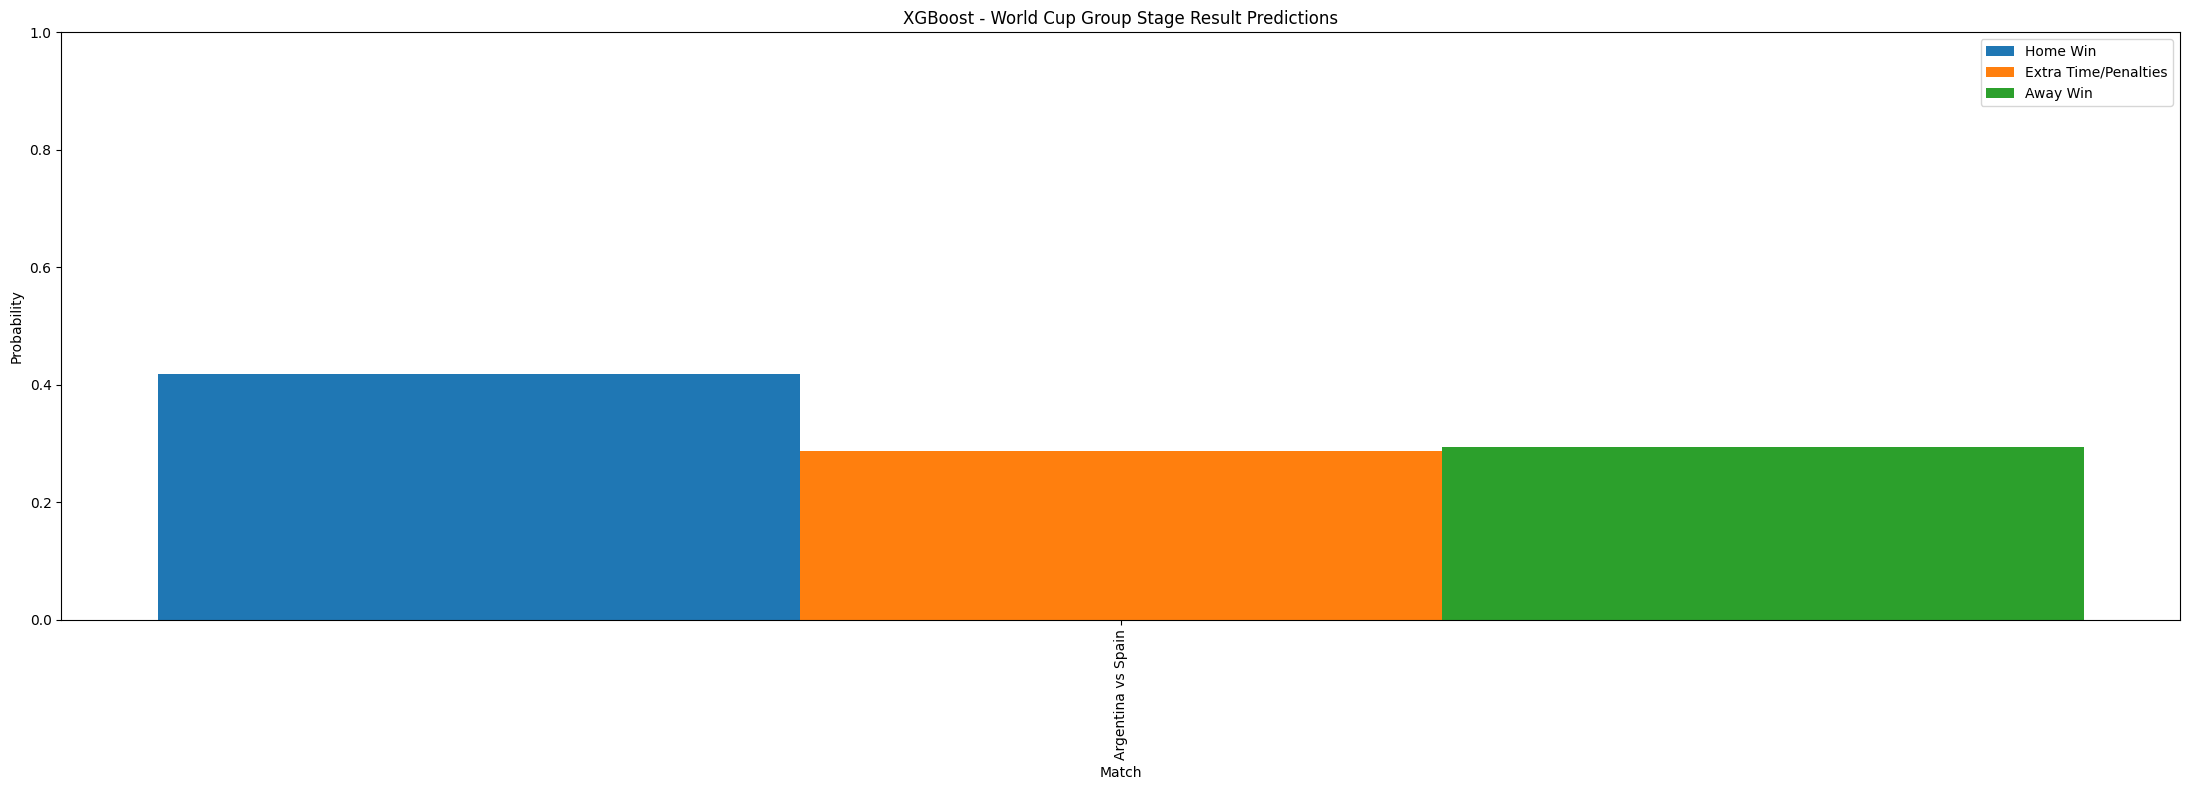

In [128]:
knockout_plot_probs(final_predictions,"XGBoost")

In [129]:
print("LR classes:", models["Logistic Regression"].classes_)
print("RF classes:", models["Random Forest"].classes_)
print("XGB classes:", models["XGBoost"].classes_)

print("\nFINAL PREDICTION:")
display(
    final_predictions[
        [
            "home_team",
            "away_team",
            "lr_prob_A",
            "lr_prob_D",
            "lr_prob_H",
            "rf_prob_A",
            "rf_prob_D",
            "rf_prob_H",
            "xgb_prob_A",
            "xgb_prob_D",
            "xgb_prob_H",
            "lr_prediction",
            "rf_prediction",
            "xgb_prediction"
        ]
    ]
)

LR classes: ['A' 'D' 'H']
RF classes: ['A' 'D' 'H']
XGB classes: [0 1 2]

FINAL PREDICTION:


,home_team,away_team,lr_prob_A,lr_prob_D,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,Argentina,Spain,0.419238,0.235117,0.345645,0.33,0.35,0.32,0.295022,0.286633,0.418345,A,A,H


In [130]:
final_spain_home = pd.DataFrame([
    {
        "date": "2026-07-19",
        "home_team": "Spain",
        "away_team": "Argentina",
        "neutral": 1,
        "tournament": "FIFA World Cup"
    }
])

final_spain_home["date"] = pd.to_datetime(
    final_spain_home["date"]
)

final_spain_home = prepare_round_features(
    final_spain_home,
    post_semi_df,
    post_semi_elo
)

pred_spain_home = predict_ko_matches(
    models,
    final_spain_home,
    features,
    scaler
)

display(pred_spain_home)

,date,home_team,away_team,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,2026-07-19,Spain,Argentina,1,FIFA World Cup,1.7,0.3,1.4,0.7,0.3,...,0.339755,0.37,0.42,0.21,0.364094,0.305704,0.330202,A,A,A


In [131]:
final_argentina_home = pd.DataFrame([
    {
        "date": "2026-07-19",
        "home_team": "Argentina",
        "away_team": "Spain",
        "neutral": 1,
        "tournament": "FIFA World Cup"
    }
])

final_argentina_home["date"] = pd.to_datetime(
    final_argentina_home["date"]
)

final_argentina_home = prepare_round_features(
    final_argentina_home,
    post_semi_df,
    post_semi_elo
)

pred_argentina_home = predict_ko_matches(
    models,
    final_argentina_home,
    features,
    scaler
)

display(pred_argentina_home)

,date,home_team,away_team,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,lr_prob_H,rf_prob_A,rf_prob_D,rf_prob_H,xgb_prob_A,xgb_prob_D,xgb_prob_H,lr_prediction,rf_prediction,xgb_prediction
0,2026-07-19,Argentina,Spain,1,FIFA World Cup,2.9,0.7,2.2,1.0,0.0,...,0.345645,0.33,0.35,0.32,0.295022,0.286633,0.418345,A,A,H


In [132]:
qf_features

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,tournament_weight,elo_home,elo_away,elo_diff
0,France,Morocco,2026-07-09,1,FIFA World Cup,2.6,0.8,1.8,0.9,0.0,...,1.6,0.7,0.3,1,0,0,5,1527.551068,1468.758947,58.792120
1,Spain,Belgium,2026-07-10,1,FIFA World Cup,1.8,0.4,1.4,0.6,0.4,...,2.5,0.7,0.3,0,0,0,5,1550.899563,1408.306945,142.592618
2,Norway,England,2026-07-11,1,FIFA World Cup,2.1,1.4,0.7,0.6,0.2,...,1.1,0.7,0.2,0,0,0,5,1406.128193,1473.366856,-67.238663
3,Argentina,Switzerland,2026-07-11,1,FIFA World Cup,2.8,0.6,2.2,1.0,0.0,...,0.8,0.5,0.4,0,0,0,5,1586.627296,1401.785139,184.842157


In [133]:
post_r16_df.tail(20)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,home_draw_rate,away_scored,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,actual_result
25418,2026-06-30,Ivory Coast,Norway,1.0,2.0,NaN,NaN,NaN,1,A,...,0.1,2.2,1.4,0.8,0.5,0.3,0,0,0,A
25419,2026-06-30,France,Sweden,3.0,0.0,NaN,NaN,NaN,1,H,...,0.1,1.8,2.1,-0.3,0.3,0.3,0,0,0,H
25420,2026-06-30,Mexico,Ecuador,2.0,0.0,NaN,NaN,NaN,1,H,...,0.2,1.2,0.6,0.6,0.4,0.5,0,1,3,H
25421,2026-07-01,United States,Bosnia and Herzegovina,2.0,0.0,NaN,NaN,NaN,1,H,...,0.0,1.6,1.2,0.4,0.3,0.6,1,0,0,H
25422,2026-07-01,Belgium,Senegal,3.0,2.0,NaN,NaN,NaN,1,H,...,0.4,1.7,1.3,0.4,0.5,0.1,0,0,0,H
25423,2026-07-01,England,DR Congo,2.0,1.0,NaN,NaN,NaN,1,H,...,0.2,1.2,0.7,0.5,0.4,0.3,0,0,0,H
25424,2026-07-02,Portugal,Croatia,2.0,1.0,NaN,NaN,NaN,1,H,...,0.4,1.9,1.5,0.4,0.7,0.0,1,1,1,H
25425,2026-07-02,Spain,Austria,3.0,0.0,NaN,NaN,NaN,1,H,...,0.4,2.6,0.9,1.7,0.6,0.2,0,0,0,H
25426,2026-07-02,Switzerland,Algeria,2.0,0.0,NaN,NaN,NaN,1,H,...,0.5,2.1,1.0,1.1,0.6,0.2,0,0,0,H
25427,2026-07-03,Colombia,Ghana,1.0,0.0,NaN,NaN,NaN,1,H,...,0.2,0.6,1.5,-0.9,0.2,0.2,0,0,0,H


In [134]:
post_r16_elo

{'Argentina': 1586.6272962421174,
 'Spain': 1550.8995631836394,
 'France': 1527.5510676239385,
 'England': 1473.366855942712,
 'Morocco': 1468.7589472189304,
 'Brazil': 1459.178533368321,
 'Portugal': 1449.019115078248,
 'Colombia': 1445.1239703276556,
 'Mexico': 1427.070512966026,
 'Netherlands': 1422.4476873393992,
 'Japan': 1414.1791651572355,
 'Germany': 1411.2544001394592,
 'Belgium': 1408.306945420767,
 'Norway': 1406.1281927167945,
 'Switzerland': 1401.7851390143828,
 'Ecuador': 1364.274913183183,
 'Italy': 1356.3141825978532,
 'Croatia': 1354.7329498048384,
 'Turkey': 1344.9150153373978,
 'Denmark': 1334.9336596597384,
 'United States': 1331.6457669683862,
 'Iran': 1327.8183198256916,
 'Austria': 1326.9347327535977,
 'Algeria': 1324.9754142963775,
 'Paraguay': 1313.3316011434858,
 'Uruguay': 1312.7507894032458,
 'Australia': 1303.03090808291,
 'Canada': 1302.9756639650968,
 'Ivory Coast': 1296.2741516565848,
 'Senegal': 1295.5426168482895,
 'Russia': 1293.743276834793,
 'South 

In [135]:
from sklearn.metrics import classification_report, confusion_matrix

for name, model in models.items():

    if name == "Logistic Regression":
        pred = model.predict(X_test_scaled)

    elif name == "XGBoost":
        pred = model.predict(X_test)
        pred = pd.Series(pred).map({
            0: "A",
            1: "D",
            2: "H"
        }).values

    else:
        pred = model.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(classification_report(
        y_test,
        pred,
        labels=["A", "D", "H"],
        digits=3,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(
        y_test,
        pred,
        labels=["A", "D", "H"]
    ))

Logistic Regression
              precision    recall  f1-score   support

           A      0.578     0.647     0.610      1071
           D      0.387     0.015     0.028       827
           H      0.626     0.872     0.729      1700

    accuracy                          0.608      3598
   macro avg      0.530     0.511     0.456      3598
weighted avg      0.557     0.608     0.532      3598

Confusion Matrix:
[[ 693   11  367]
 [ 297   12  518]
 [ 210    8 1482]]
Random Forest
              precision    recall  f1-score   support

           A      0.570     0.615     0.592      1071
           D      0.300     0.058     0.097       827
           H      0.631     0.846     0.723      1700

    accuracy                          0.596      3598
   macro avg      0.500     0.507     0.471      3598
weighted avg      0.537     0.596     0.540      3598

Confusion Matrix:
[[ 659   64  348]
 [ 284   48  495]
 [ 213   48 1439]]
XGBoost
              precision    recall  f1-score   supp

In [136]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    models["Logistic Regression"],
    "models/logistic_model.pkl"
)

joblib.dump(
    models["Random Forest"],
    "models/random_forest_model.pkl"
)

joblib.dump(
    models["XGBoost"],
    "models/xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "models/result_scaler.pkl"
)

print("✅ All models saved.")

✅ All models saved.


In [137]:
print(os.listdir("models"))

['away_goal_model.pkl', 'home_goal_model.pkl', 'logistic_model.pkl', 'random_forest_model.pkl', 'result_scaler.pkl', 'score_scaler.pkl', 'xgboost_model.pkl']


In [138]:
import joblib

lr = joblib.load("models/logistic_model.pkl")
rf = joblib.load("models/random_forest_model.pkl")
xgb = joblib.load("models/xgboost_model.pkl")
scaler = joblib.load("models/result_scaler.pkl")

print("LR classes :", lr.classes_)
print("RF classes :", rf.classes_)
print("XGB classes:", xgb.classes_)

print("LR features :", lr.n_features_in_)
print("RF features :", rf.n_features_in_)
print("XGB features:", xgb.n_features_in_)
print("Scaler features:", scaler.n_features_in_)

LR classes : ['A' 'D' 'H']
RF classes : ['A' 'D' 'H']
XGB classes: [0 1 2]
LR features : 18
RF features : 18
XGB features: 18
Scaler features: 18
